# DSAA2011 Final Project: Graph-Aware Detection of Rare AML Transactions

**Team:** Bokang GAO, Zi Xuan SZETO, and Minghua XIONG

This notebook documents the full analytical path of our IBM synthetic anti-money-laundering (AML) project. The goal is not simply to maximize a classification score. In practice, an AML model sits between a high-volume payment stream and a limited team of investigators. A useful system must therefore do three things at once: rank rare suspicious activity, avoid an unmanageable number of false alerts, and use only information that would have been available when a transaction occurred.

Our central research question is:

> **Does account-level graph context improve transaction-level AML detection, and does that improvement survive realistic changes in class prevalence and time?**

The notebook follows the way the investigation developed rather than presenting only the final model:

1. establish the extreme class imbalance and the failure of accuracy as a primary metric;
2. inspect transaction structure through EDA and t-SNE;
3. test whether KMeans or DBSCAN can discover suspicious account groups without labels;
4. move from linear baselines to nonlinear ensembles after observing overlap and interactions;
5. add account graph features and quantify their contribution through ablation;
6. stress-test the best sampled model at the natural class prior; and
7. diagnose why a frozen graph snapshot fails under chronology; and
8. repair the feature construction with strict expanding history and retest the graph hypothesis.

The strongest result is intentionally not treated as the final word. The random-split graph model is useful evidence, but natural prevalence and feature availability define how far it can be generalized. The final temporal experiment therefore treats a failed audit as a design problem and tests a leakage-safe repair.


## 1. Reproducible notebook setup

The first code cell imports only lightweight review dependencies and defines paths relative to the extracted project root. The assertion is deliberate: it prevents the notebook from silently reading artifacts from an unintended directory. `RESULTS` contains machine-readable tables and `FIGURES` contains plots generated by the experiment scripts.

This separation keeps the analysis reproducible at two levels. A reviewer can execute the notebook quickly from the submitted ZIP, while a researcher with the raw data can regenerate every artifact through the full-pipeline switch below.


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
assert (ROOT / "results").exists(), (
    "Please run this notebook from the extracted project root."
)
FIGURES = ROOT / "figures"
RESULTS = ROOT / "results"

The setup cell performs no modeling and changes no data. It creates one explicit project root and two reusable artifact locations so that every later cell can be read independently. `pandas` is used for transparent tabular inspection, while `IPython.display` embeds the exact saved figures used in the report.


## 2. Quick review versus full regeneration

The submitted notebook defaults to **quick-review mode** because the original workflow processes more than five million transactions. In quick mode, cells read the preserved CSV, JSON, and PNG artifacts, so all reported outputs remain visible and the notebook can be checked on an ordinary machine.

Setting `RUN_FULL_PIPELINE = True` runs two scripts in sequence:

| Script | Main responsibility |
|---|---|
| `src/aml_project_pipeline.py` | chunked data processing, EDA, t-SNE, supervised baselines and ensembles, ROC/PR curves, and train/test/full metrics |
| `src/aml_project_enhancements.py` | account clustering, feature-selection ablations, natural-prior stress testing, and the legacy frozen-snapshot audit |
| `src/aml_project_model_selection.py` | 3-fold GridSearchCV, out-of-fold threshold selection, strict expanding-history graph features, temporal ablation, and bootstrap uncertainty |

The raw dataset must be available for full regeneration. Keeping the expensive work in scripts also avoids hiding multi-stage processing inside a very long notebook cell.


In [2]:
RUN_FULL_PIPELINE = False

if RUN_FULL_PIPELINE:
    !{sys.executable} src/aml_project_pipeline.py
    !{sys.executable} src/aml_project_enhancements.py
    !{sys.executable} src/aml_project_model_selection.py


With the default value `False`, this cell intentionally produces no output: it confirms that review mode is active. All following numbers still come from executed experiments, not hand-entered examples. The distinction is computational, not analytical.


## 3. Implementation map and code ownership

The notebook is the technical entry point, while reusable functions live in three submitted Python modules. This is not an artifact-only notebook: full mode executes every module, and the implementation appendix displays their complete source verbatim. The small inspection cell below checks file size, function count, and module documentation before any result is interpreted.

Keeping preprocessing inside `sklearn.Pipeline` is especially important. During cross-validation, each fold must learn its imputer, scaler, and one-hot vocabulary from that fold's training portion rather than from the complete modeling sample.


In [3]:
# Verify that every core module is present and structurally documented.
import ast

source_inventory = []
for source_name in [
    "aml_project_pipeline.py",
    "aml_project_enhancements.py",
    "aml_project_model_selection.py",
]:
    source_path = ROOT / "src" / source_name
    source_text = source_path.read_text(encoding="utf-8")
    syntax_tree = ast.parse(source_text)
    source_inventory.append(
        {
            "module": source_name,
            "lines": len(source_text.splitlines()),
            "functions": sum(isinstance(node, ast.FunctionDef) for node in syntax_tree.body),
            "module_docstring": bool(ast.get_docstring(syntax_tree)),
        }
    )
pd.DataFrame(source_inventory)


,module,lines,functions,module_docstring
0,aml_project_pipeline.py,863,16,True
1,aml_project_enhancements.py,647,13,True
2,aml_project_model_selection.py,665,9,True


The three modules separate mandatory tasks, open-ended diagnostics, and the final methodological repair. This makes the experiment path auditable: the original random/transductive result and failed frozen-snapshot audit remain reproducible rather than being overwritten by the improved method.


## 4. Dataset scale, rarity, and initial EDA

Before choosing a model, we first ask whether the target can be evaluated with ordinary accuracy. Full-data statistics are computed in chunks so the base rate reflects the complete dataset rather than the enriched modeling sample. We also compare laundering rates across payment formats as a first check for heterogeneous risk.

The code below reads `dataset_stats.json` and `payment_format_rates.csv`. It does not fit a model. This matters because descriptive rates can guide feature engineering, but they should not be mistaken for causal risk estimates.


In [4]:
# Read full-dataset counts and payment-format rates generated by the chunked pipeline.
stats=json.loads((RESULTS/'dataset_stats.json').read_text(encoding='utf-8'))
print(stats['total_rows'], stats['positive_rows'], stats['positive_rate'])
pd.read_csv(RESULTS/'payment_format_rates.csv')

5078345 5177 0.0010194266045335635


,Payment Format,transactions,laundering,laundering_rate
0,ACH,600797,4483,0.007462
1,Bitcoin,146091,56,0.000383
2,Cash,490891,108,0.000220
3,Cheque,1864331,324,0.000174
4,Credit Card,1323324,206,0.000156
5,Reinvestment,481056,0,0.000000
6,Wire,171855,0,0.000000


### What we learned from the counts

The full dataset contains **5,078,345 transactions** but only **5,177 laundering labels**, a positive rate of **0.1019%**. A classifier that predicts every transaction as legitimate would therefore exceed 99.8% accuracy while detecting no laundering. This immediately changes our evaluation priorities: recall, F1, PR-AUC, and the number of false alerts are more informative than accuracy alone.

Payment-format rates are also highly uneven. ACH has the highest observed laundering rate in this synthetic dataset (about 0.746%), whereas several formats are near zero. We retain payment format through one-hot encoding, but interpret the pattern cautiously: it can reflect the dataset-generating process and should not become a rule that treats one payment channel as inherently criminal.


The next cell displays two complementary views. The payment-format chart compares categorical rates, while the amount chart uses a log-oriented view to make a long-tailed monetary distribution readable. Together they test a simple initial hypothesis: perhaps laundering can be identified by one obvious channel or unusually large amounts.


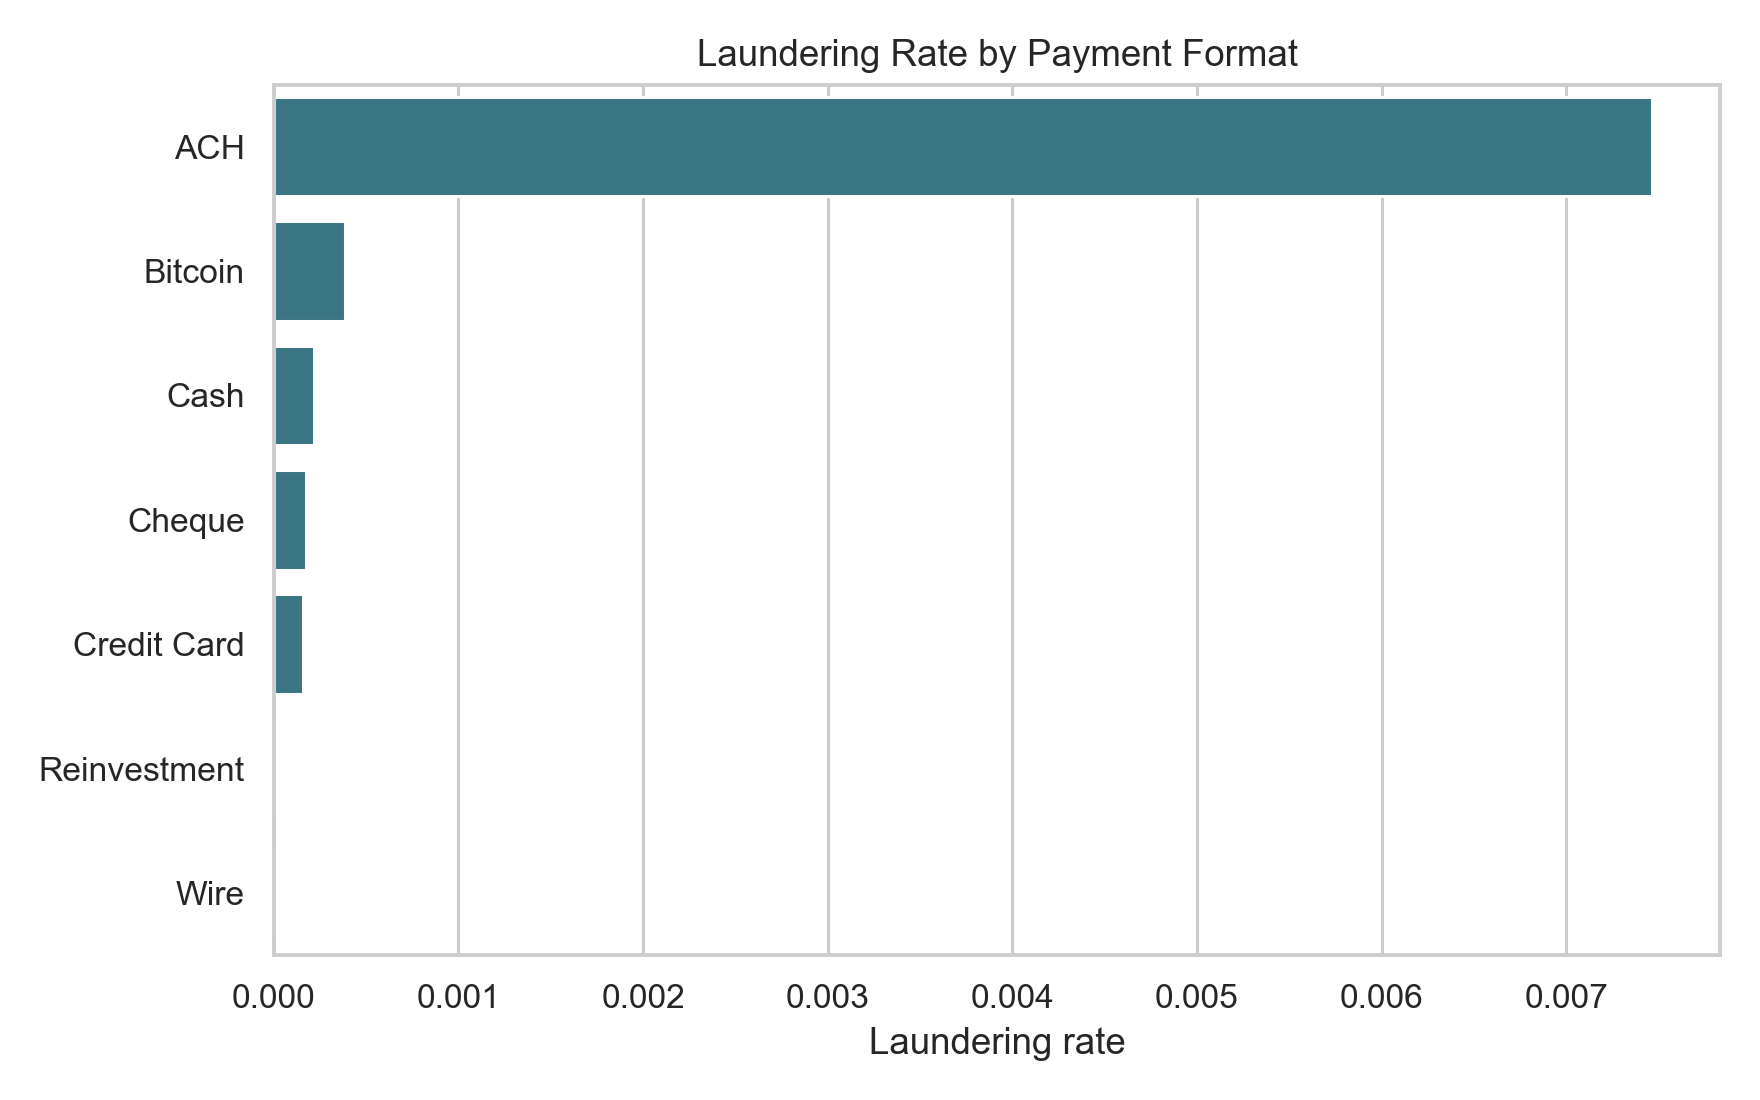

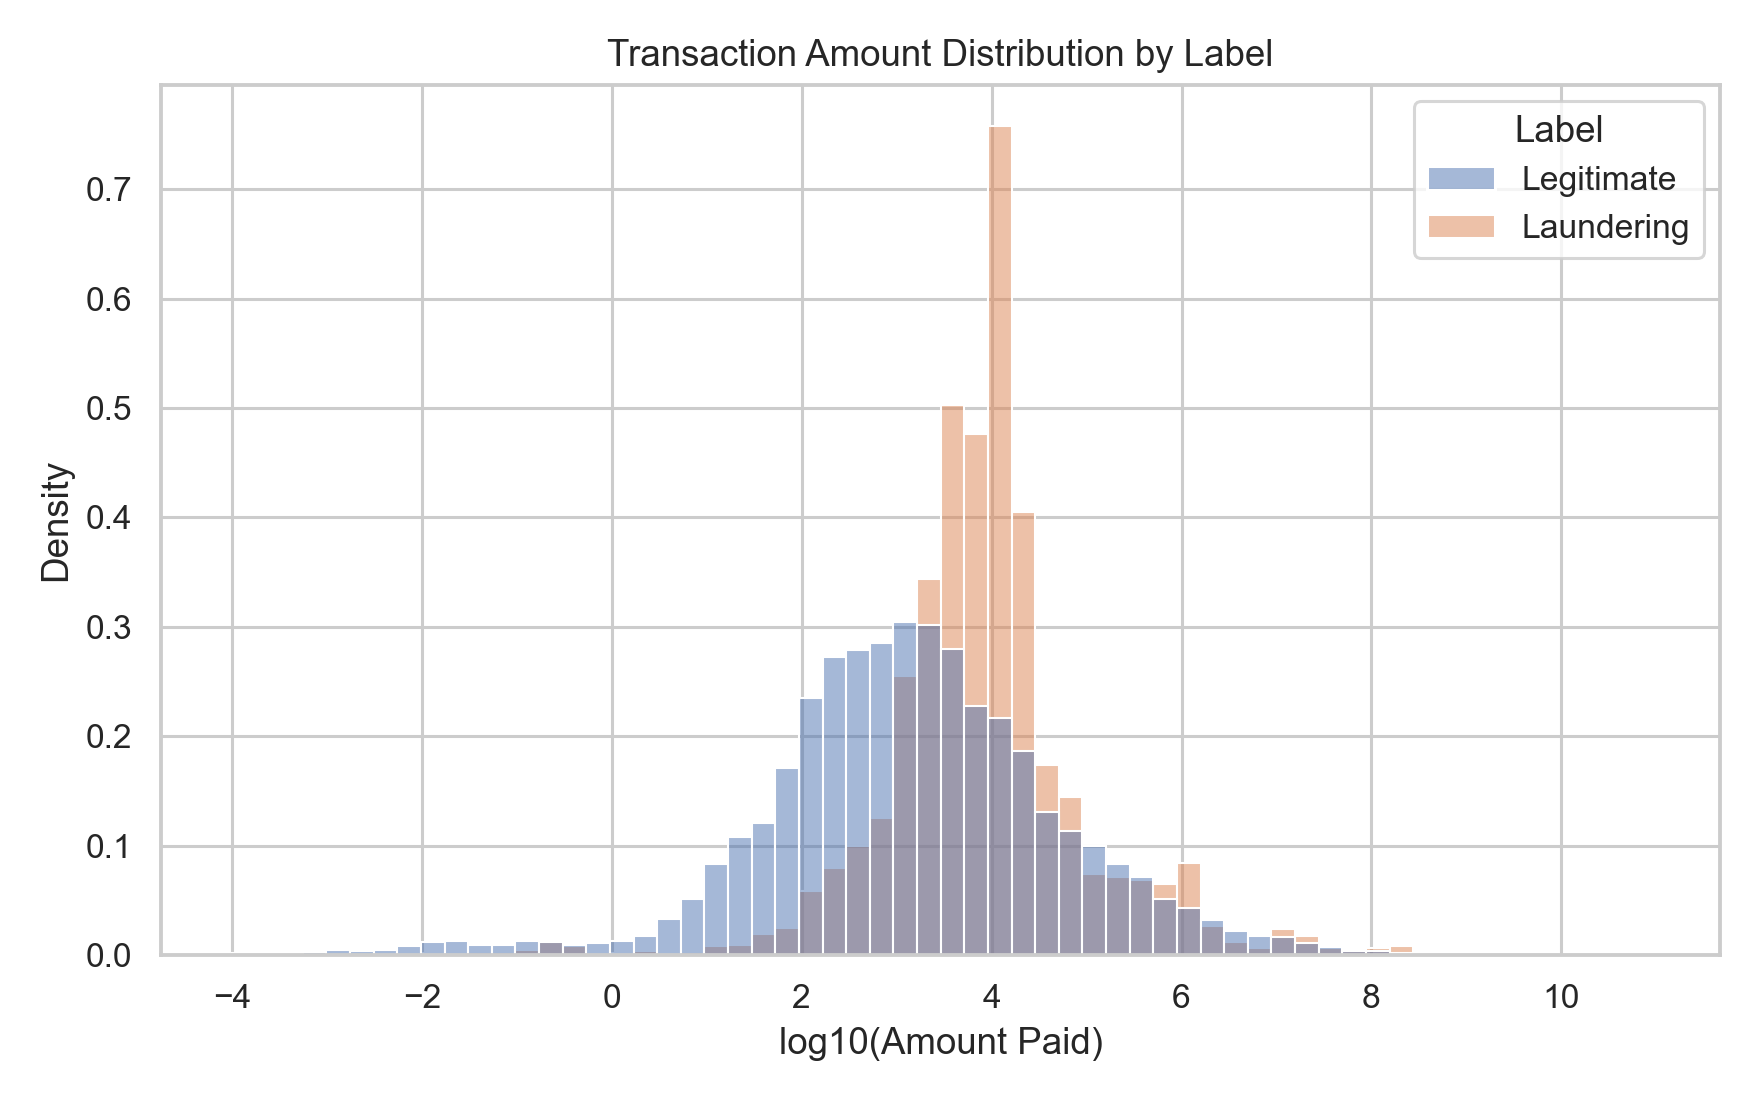

In [5]:
# Display the exact EDA figures used to motivate multivariate feature engineering.
display(Image(filename=str(FIGURES/'eda_payment_format_rate.png')))
display(Image(filename=str(FIGURES/'eda_amount_distribution.png')))

### EDA decision

Neither amount nor payment format provides a complete separation. Large values occur in legitimate transactions, and suspicious labels are not confined to one format. This is our first useful failure: fixed rules based on a single transaction attribute are unlikely to be sufficient. We therefore engineer time, amount, bank/currency relationship, and account-behavior features and examine their joint structure.


## 5. t-SNE: useful structure without clean separation

t-SNE is applied to a stratified transaction sample after preprocessing. It is used here as an exploratory visualization, not as a classifier. The method preserves local neighborhoods more strongly than global distances, so isolated visual islands can suggest subgroups but cannot establish decision boundaries or deployment performance.

The sampling strategy makes rare positive points visible; it also means the apparent density in the plot is not the natural transaction prevalence.


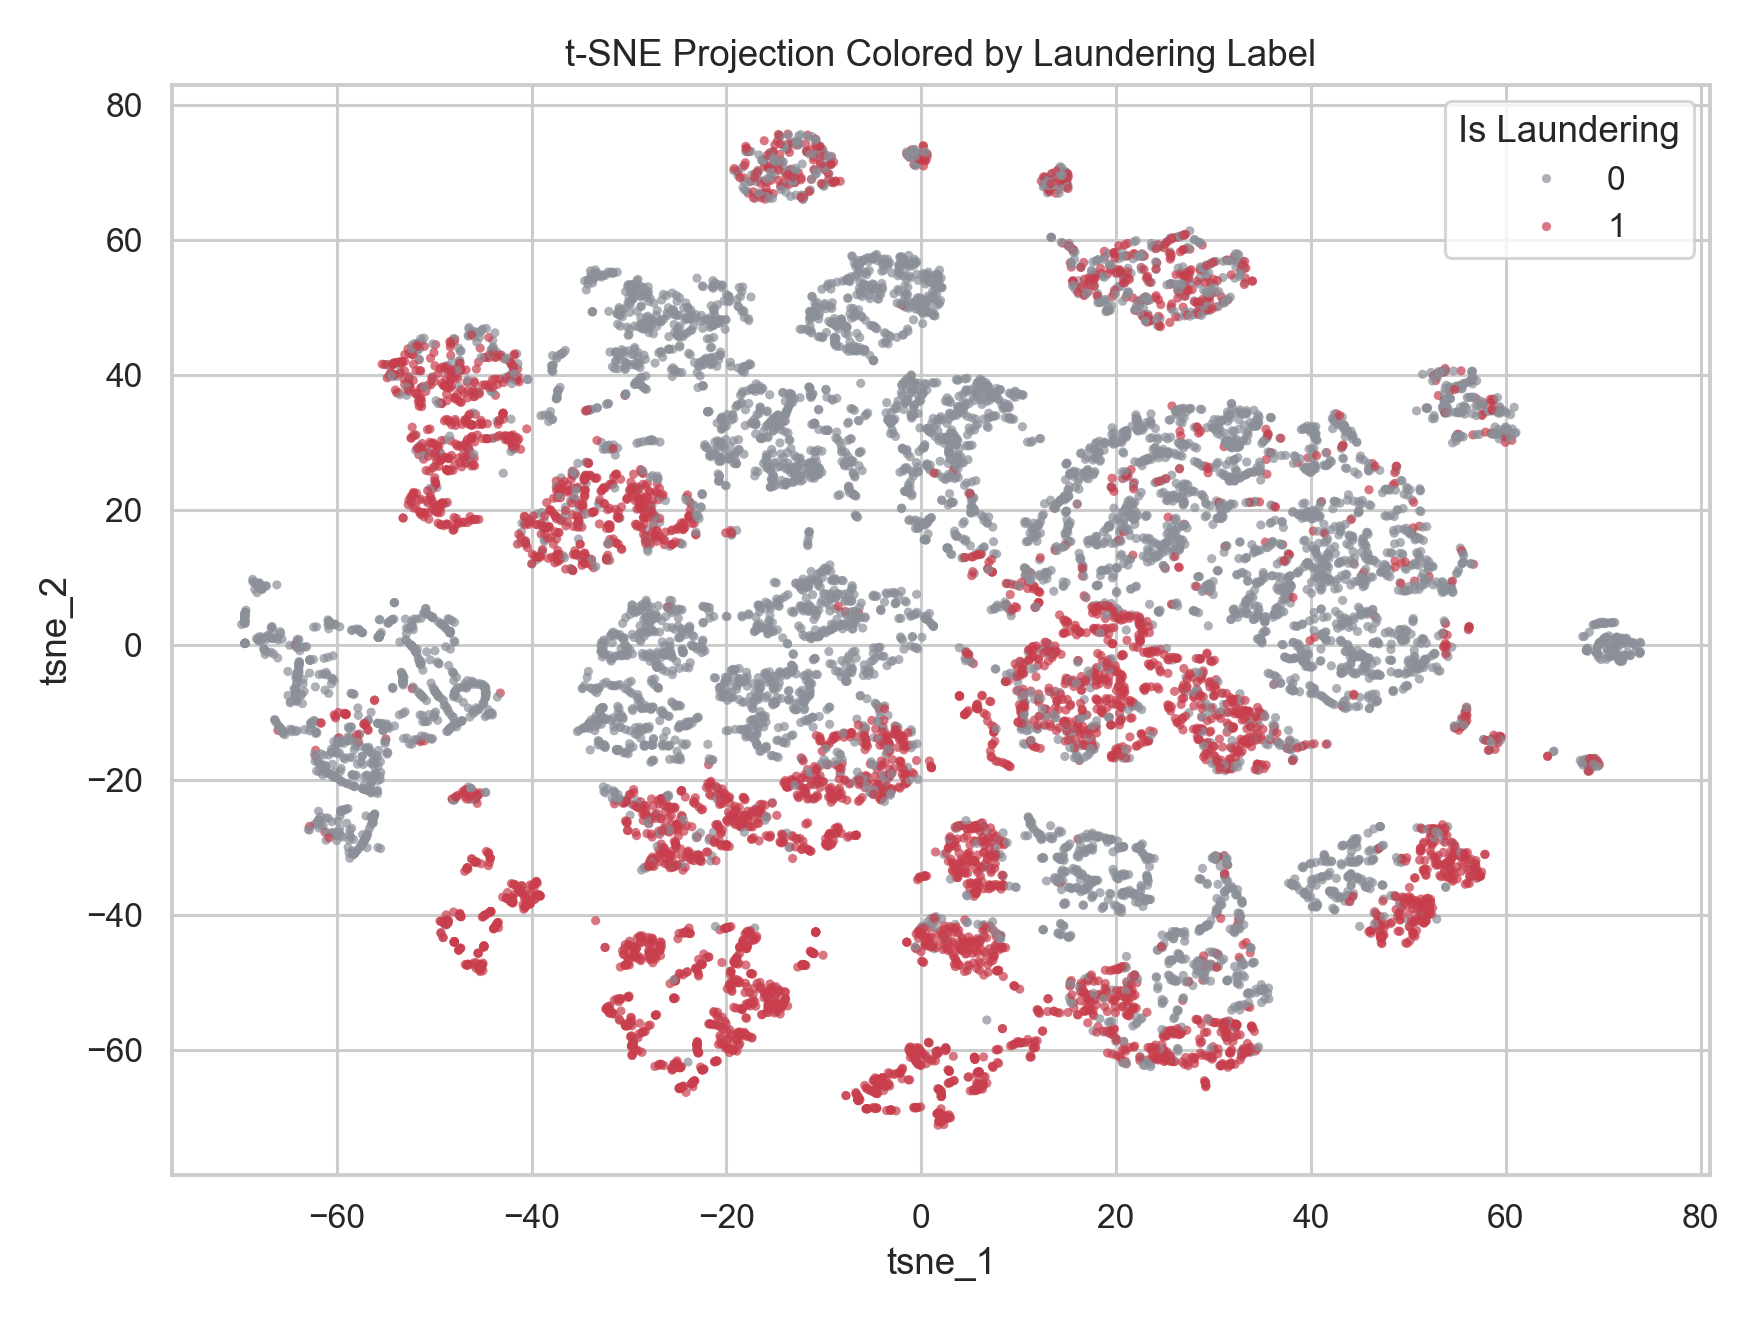

In [6]:
# Display the saved stratified t-SNE embedding; this is exploratory, not predictive.
display(Image(filename=str(FIGURES/'tsne_projection.png')))

### Interpretation and next step

Laundering observations form several local concentrations but overlap substantially with legitimate transactions. This mixed geometry explains why a single linear boundary may struggle and motivates nonlinear models. At the same time, the visible neighborhoods suggest that local or account-context patterns may contain useful information. The next experiment asks whether those patterns can be recovered without labels.


## 6. Mandatory clustering: KMeans and DBSCAN at account level

AML behavior often belongs to an account pattern rather than one payment. We therefore aggregate transactions into account-level behavior features, including sent/received counts, counterparty diversity, fan-in, fan-out, flow balance, and scatter-gather proxies.

KMeans tests whether accounts form compact global groups. DBSCAN tests a different idea: dense regions may represent common behavior while sparse points are potential anomalies. We report:

- **Silhouette:** geometric cohesion, independent of the AML label;
- **NMI and ARI:** agreement between clusters and the known laundering-account label;
- **Purity:** included for completeness, but potentially inflated by imbalance; and
- **maximum cluster positive rate:** a profiling signal, not an overall accuracy measure.


In [7]:
# Compare account-level KMeans and DBSCAN with geometry and label-agreement metrics.
pd.read_csv(RESULTS/'account_clustering_metrics.csv')

,method,n_clusters_ex_noise,noise_rate,silhouette,nmi,ari,purity,cluster_positive_rate_max
0,Account KMeans,6,0.00000,0.380128,0.021365,0.016983,0.758812,0.423920
1,Account DBSCAN,2,0.00626,0.477664,0.000524,-0.008317,0.762637,0.848485


### Clustering metrics: geometry is not the same as the target

DBSCAN has the higher silhouette score (0.478 versus 0.380), suggesting more coherent density structure among its regions. However, both NMI and ARI are near zero. KMeans NMI/ARI are 0.021/0.017, while DBSCAN NMI/ARI are 0.001/-0.008. Thus, the unsupervised geometry does **not** reproduce the laundering labels reliably.

Purity around 0.76 is not evidence of strong detection because a dominant class can make purity look favorable. This is why multiple clustering metrics are necessary.


The profile table below sorts account groups by their observed laundering-account rate and exposes the behavior averages behind each group. The rows combine KMeans profiles and DBSCAN profiles, so `NaN` in one cluster column means that the row belongs to the other method rather than indicating missing source data.


In [8]:
# Inspect the behavior profile behind high-risk clusters and the DBSCAN noise group.
pd.read_csv(RESULTS/'account_cluster_profiles.csv').sort_values('laundering_account_rate', ascending=False).head(8)

,kmeans_cluster,accounts,laundering_accounts,avg_sent_count,avg_received_count,avg_fan_out,avg_fan_in,avg_scatter_gather,laundering_account_rate,method,dbscan_cluster
6,NaN,165,140,94.103030,8.800000,0.413903,0.689321,10.117650,0.848485,dbscan_cluster,-1.0
2,2.0,2918,1237,7.032214,1.748115,0.541187,0.516423,1.628877,0.423920,kmeans_cluster,NaN
3,3.0,1237,450,0.545675,3.953112,0.065573,0.479815,0.405253,0.363783,kmeans_cluster,NaN
5,5.0,5591,1479,0.007691,1.269540,0.002137,0.497421,0.481011,0.264532,kmeans_cluster,NaN
8,NaN,18533,4523,0.701613,1.445745,0.207975,0.492927,0.736665,0.244051,dbscan_cluster,1.0
0,0.0,4307,1049,1.481542,1.253541,0.505442,0.498777,1.084901,0.243557,kmeans_cluster,NaN
4,4.0,7671,1704,1.652979,0.000391,0.504399,0.000065,2.348977,0.222135,kmeans_cluster,NaN
7,NaN,7659,1694,1.562345,0.000000,0.504106,0.000000,2.305784,0.221178,dbscan_cluster,0.0


The largest displayed rate, **0.848**, belongs specifically to the small DBSCAN noise/outlier group with label `-1` in the modeling account sample. It is not 84.8% classification accuracy, overall purity, or expected precision under the natural class prior. Its defensible use is investigative: the outlier group has unusually concentrated behavior and is worth profiling, but DBSCAN cannot replace supervised detection.


The following PCA views provide a common two-dimensional coordinate system for comparing the true account label, KMeans assignments, and DBSCAN assignments. PCA is used for display only; the clustering algorithms operate on the prepared account features rather than on conclusions drawn from the picture.


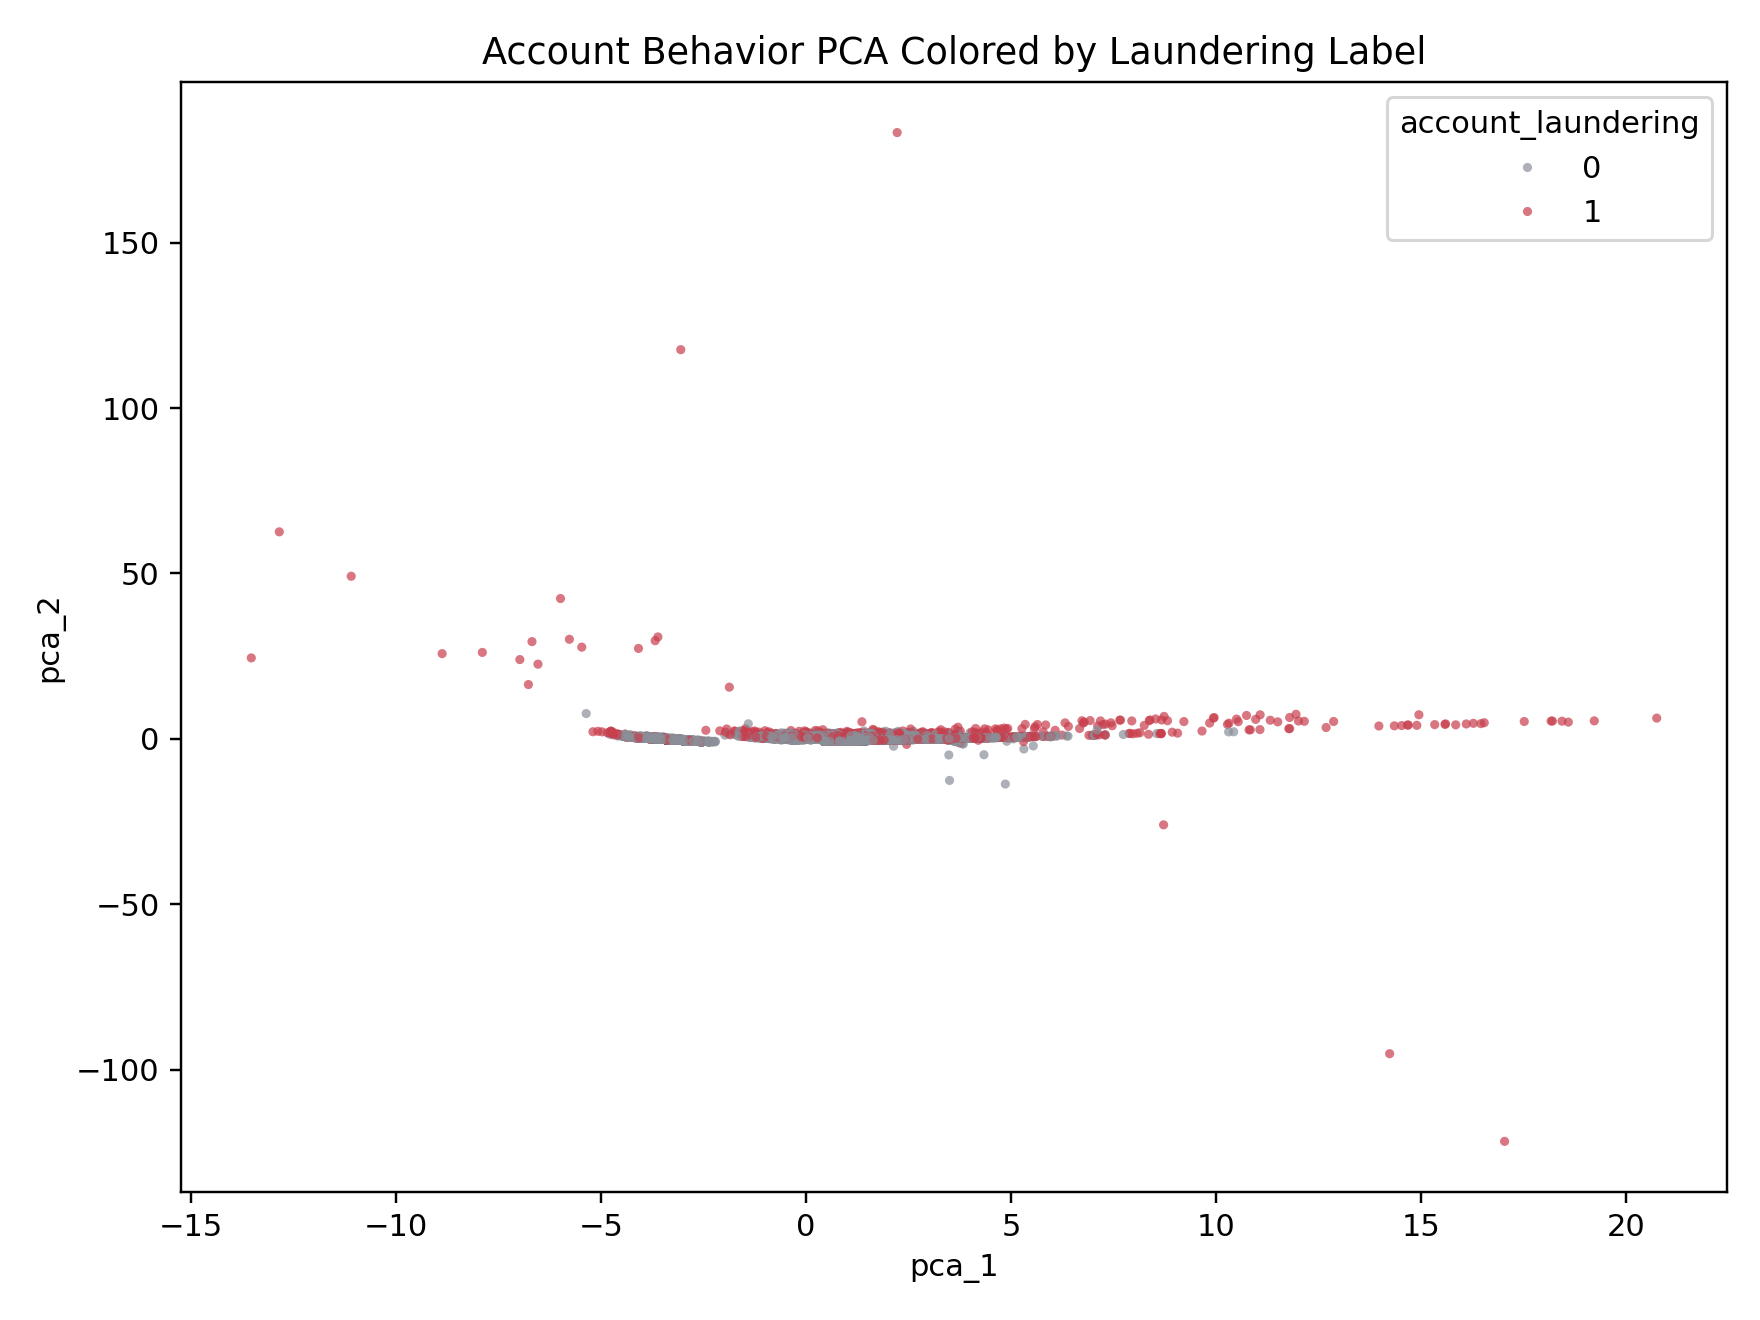

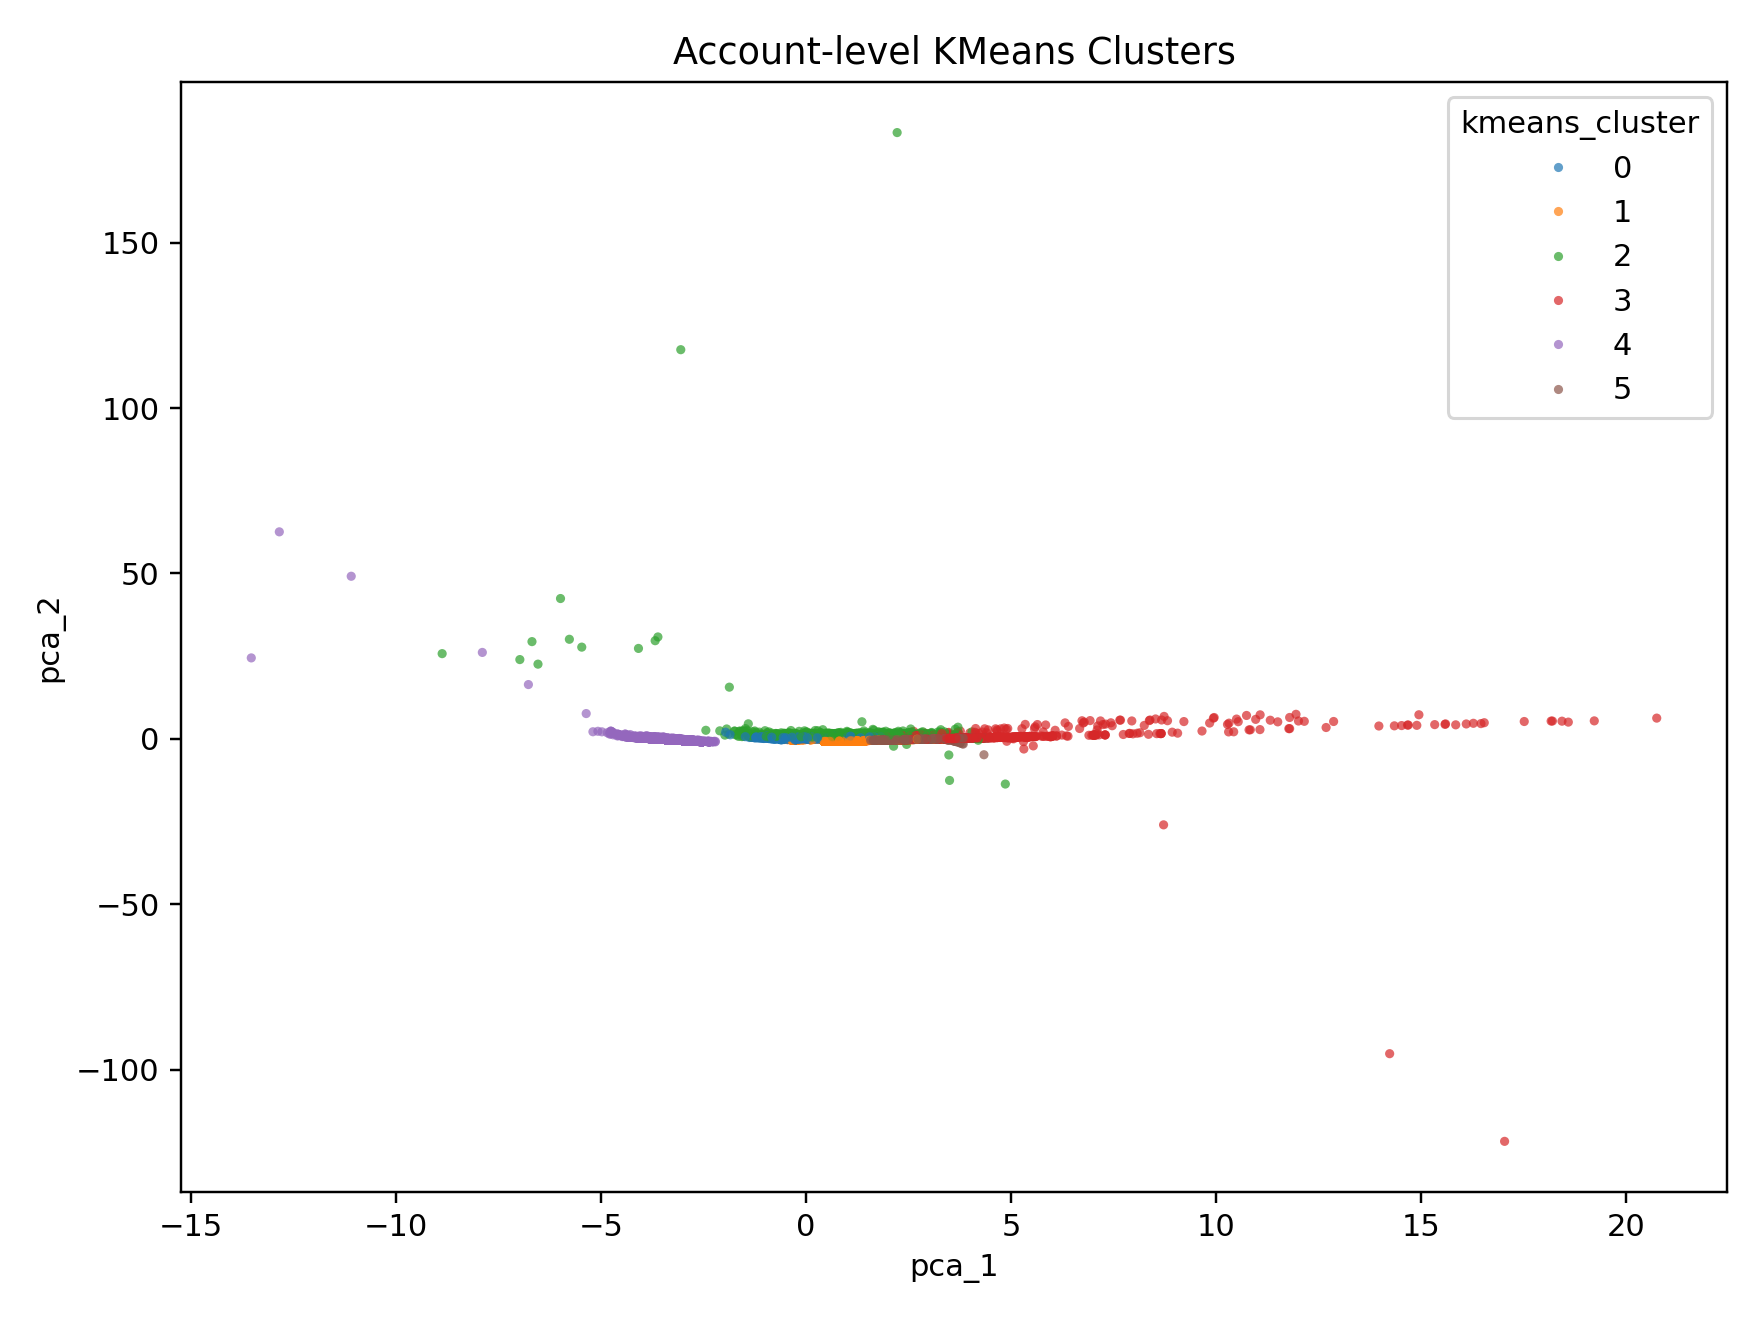

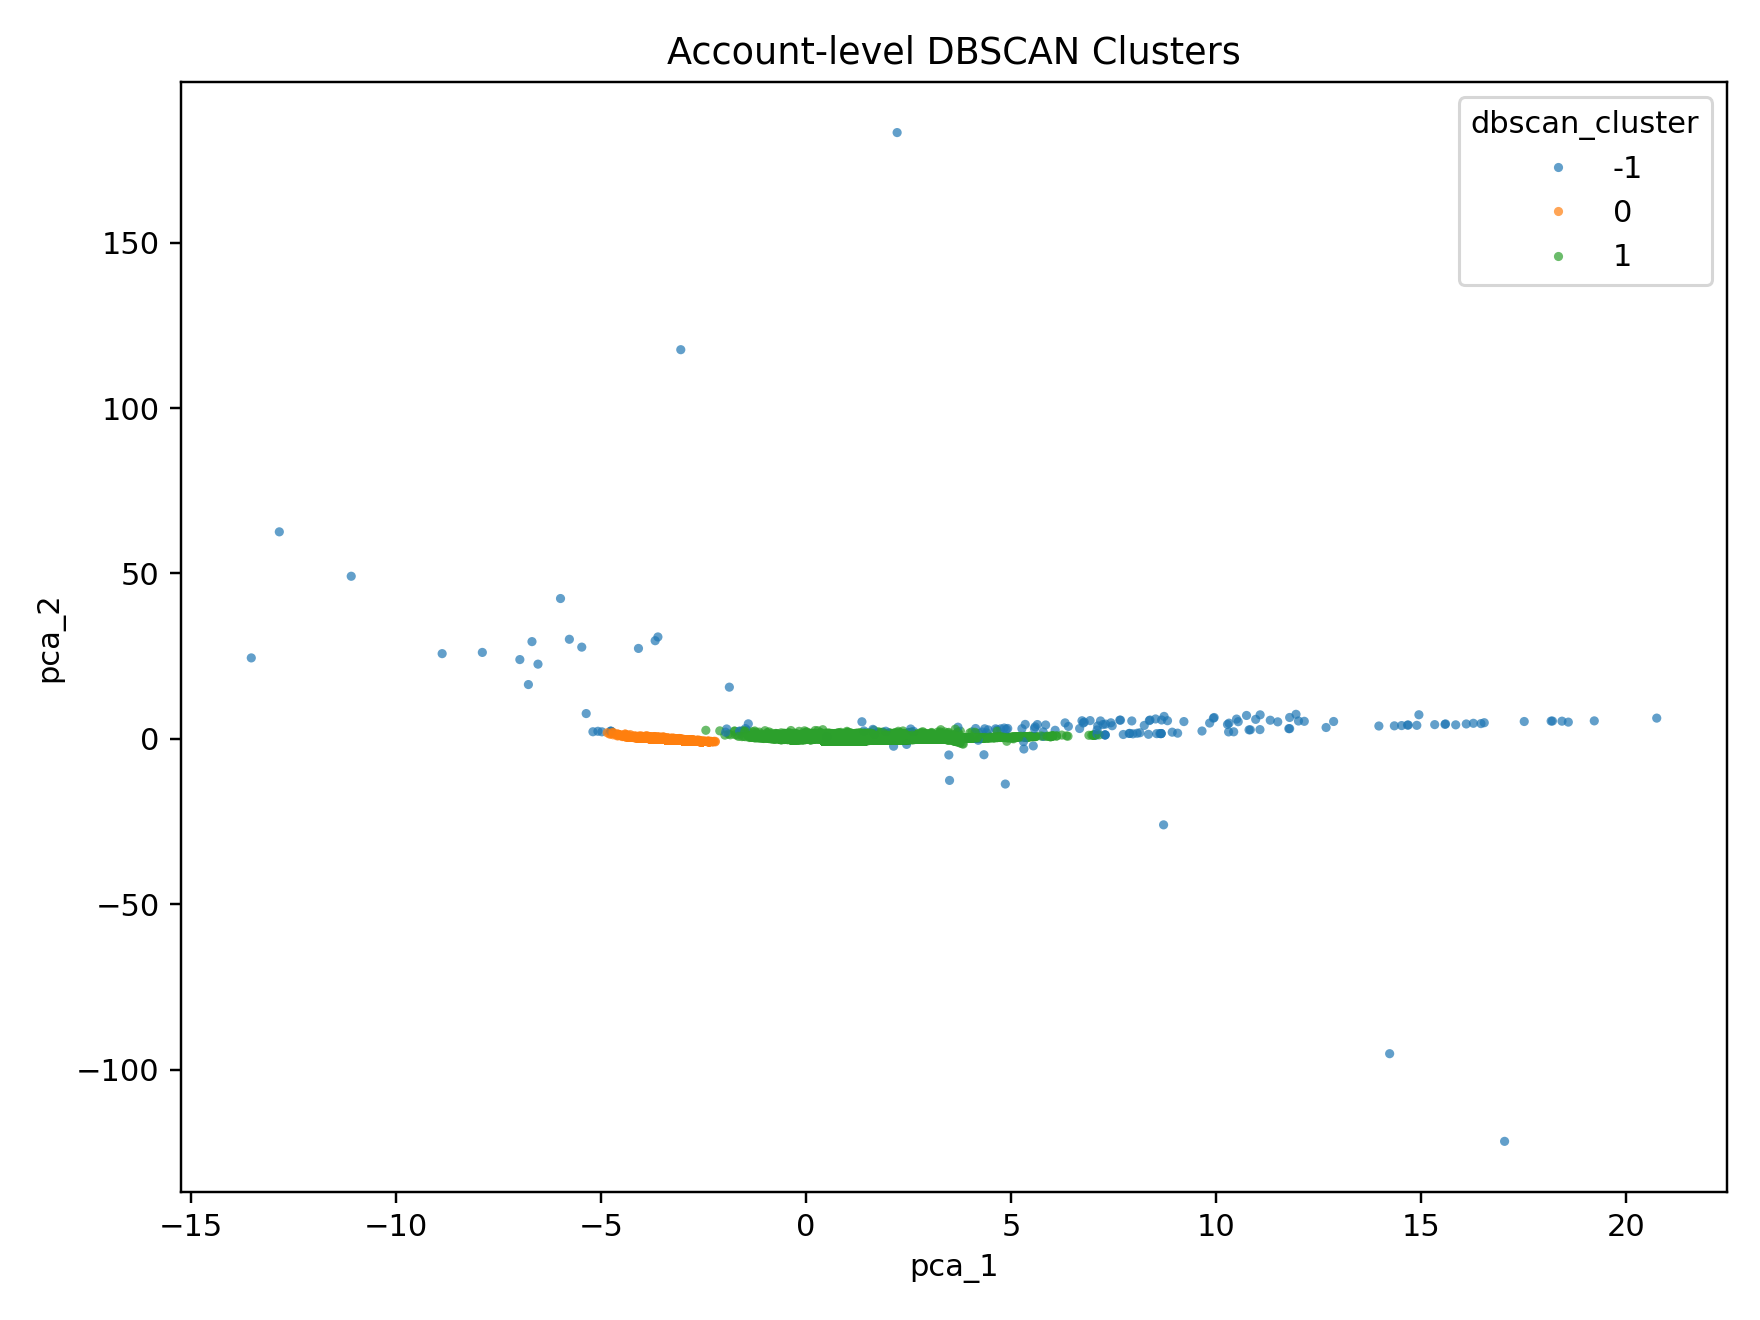

In [9]:
# Use a shared PCA display space to compare labels with both clustering assignments.
display(Image(filename=str(FIGURES/'account_pca_by_laundering.png')))
display(Image(filename=str(FIGURES/'account_kmeans_clusters.png')))
display(Image(filename=str(FIGURES/'account_dbscan_clusters.png')))

### Failure mode 1: unsupervised clusters are exploratory, not predictive

The visualizations confirm a few localized suspicious regions but substantial label mixing remains. We keep clustering because it can surface unusual account cohorts for investigation, yet the low NMI/ARI prevents us from presenting it as a detector. This failure motivates the supervised stage, where labels can guide the boundary while the account features retain behavioral context.


## 7. Supervised model path: from the accuracy trap to graph-aware ensembles

The model sequence is deliberately progressive:

1. **Dummy All-Legitimate** quantifies the accuracy illusion.
2. **Logistic Regression** is the interpretable linear baseline required by the course design.
3. **Linear SVM** checks whether another linear margin changes the result.
4. **Decision Tree** introduces nonlinear interactions but may be unstable.
5. **Random Forest** reduces single-tree variance.
6. **HistGradientBoosting (HGB)** models nonlinear interactions efficiently.
7. RF and HGB are each compared with and without graph features.

For every trainable model, the decision threshold is selected on a validation split inside the training data. The final test labels are not used to choose that threshold. The table below reports test-set metrics from the enriched modeling sample.


In [10]:
# Compare mandatory baselines and nonlinear base/graph models on the held-out sampled test set.
pd.read_csv(RESULTS/'metrics_summary.csv')[['model','accuracy','precision','recall','f1','roc_auc','pr_auc']]

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,HistGradientBoosting + Graph Features,0.978064,0.670322,0.590470,0.627867,0.976154,0.721247
1,Random Forest + Graph Features,0.970981,0.529292,0.669028,0.591013,0.972061,0.680738
2,HistGradientBoosting Base Features,0.966663,0.475700,0.623954,0.539833,0.930407,0.555632
3,Random Forest Base Features,0.962102,0.433155,0.678042,0.528614,0.926696,0.550176
4,Decision Tree,0.946261,0.339781,0.757888,0.469205,0.906235,0.405416
5,Linear SVM,0.950115,0.347696,0.675467,0.459081,0.914759,0.327055
6,Logistic Regression,0.950761,0.349915,0.665808,0.458740,0.914552,0.337851
7,Dummy All-Legitimate,0.968660,0.000000,0.000000,0.000000,0.500000,0.031340


### Model comparison result

The dummy model obtains 0.969 accuracy and zero recall, proving that accuracy rewards the wrong behavior in this task. Logistic Regression and Linear SVM have nearly identical F1 (about 0.459), which supports the t-SNE observation that one linear boundary is insufficient. A Decision Tree raises recall but still ranks cases less effectively than the ensembles.

The strongest sampled-test model is **HGB + Graph Features**, with precision 0.670, recall 0.590, F1 0.628, ROC-AUC 0.976, and PR-AUC 0.721. PR-AUC is emphasized because it measures ranking quality for the rare positive class and reacts more strongly than ROC-AUC to false positives. These values answer a controlled model-comparison question; they do not yet estimate production precision.


## 8. Formal cross-validation and grid search

The first model table used fixed, reasoned hyperparameters and a validation-selected threshold. To satisfy a stricter model-selection standard, we now tune Logistic Regression, Decision Tree, Random Forest, and HGB with **3-fold stratified GridSearchCV on the 70% training partition only**.

The search uses mean validation PR-AUC (`average_precision`) as the refit criterion because the positive class is rare. Imputation, scaling, and one-hot encoding stay inside each pipeline and are refitted inside every fold. After selecting hyperparameters, out-of-fold training scores choose the F1 threshold; the 30% test partition remains untouched until final evaluation.


In [11]:
# Show cross-validation stability, selected parameters, and one-time test results.
cv_summary = pd.read_csv(RESULTS / "cross_validation_summary.csv")
cv_summary[
    [
        "model",
        "feature_set",
        "best_cv_pr_auc_mean",
        "best_cv_pr_auc_std",
        "best_params",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_pr_auc",
    ]
]


,model,feature_set,best_cv_pr_auc_mean,best_cv_pr_auc_std,best_params,test_precision,test_recall,test_f1,test_pr_auc
0,HistGradientBoosting,base+retrospective_graph,0.721075,0.005125,"{""model__l2_regularization"": 1.0, ""model__lear...",0.624296,0.641983,0.633016,0.723433
1,HistGradientBoosting,base,0.560869,0.009001,"{""model__l2_regularization"": 0.0, ""model__lear...",0.513992,0.579524,0.544794,0.555662
2,Random Forest,base,0.553447,0.011005,"{""model__max_depth"": 18, ""model__min_samples_l...",0.467015,0.633612,0.537705,0.553106
3,Decision Tree,base,0.467703,0.010618,"{""model__max_depth"": 15, ""model__min_samples_l...",0.434372,0.592402,0.501226,0.476920
4,Logistic Regression,base,0.328756,0.009148,"{""model__C"": 0.1}",0.338825,0.701867,0.457023,0.346391


### Cross-validation result

The tuned retrospective graph HGB has the highest mean CV PR-AUC, **0.721 +/- 0.005**, and test PR-AUC **0.723**. Its low fold-to-fold standard deviation indicates that the ranking advantage is not driven by one fortunate validation split. Among base-only models, HGB (0.561 CV PR-AUC) and Random Forest (0.553) outperform the Decision Tree (0.468) and Logistic Regression (0.329), preserving the original nonlinear-model ordering.

Grid search does not remove the protocol limitation: the retrospective graph columns are still aggregates over the randomly partitioned modeling graph. The result strengthens model selection within that protocol, while the temporal section separately tests whether the representation is available prospectively.


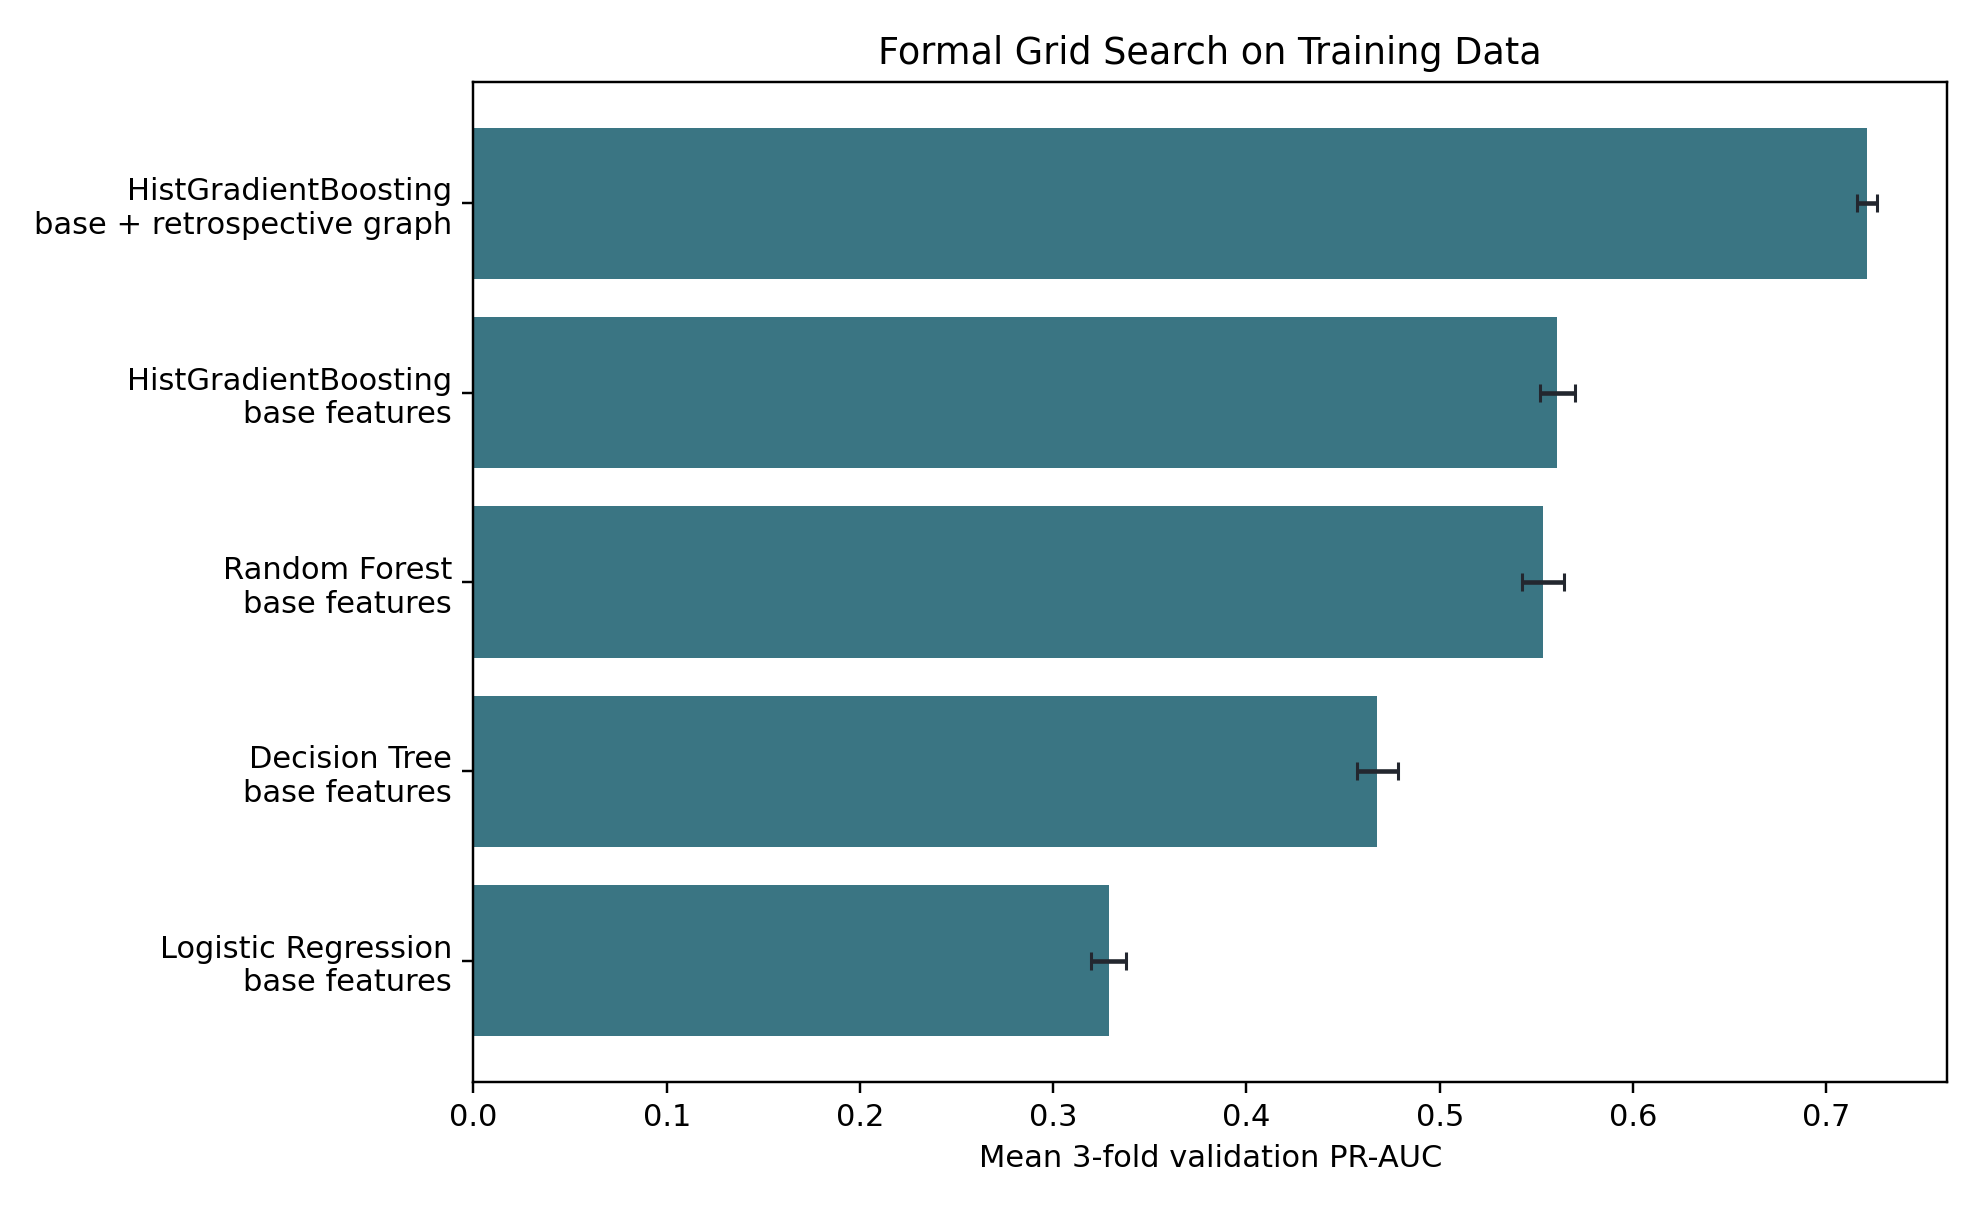

In [12]:
# Error bars show the standard deviation across the three validation folds.
display(Image(filename=str(FIGURES / "cross_validation_pr_auc.png")))


## 9. Train, test, and full modeling-sample evaluation

The next table makes the split protocol auditable. For each model it records the validation-selected threshold, train/test/full metrics, and all four confusion-matrix counts. Reading the counts alongside rates prevents a seemingly small false-positive rate from hiding a large alert workload.

The `full` row is the union of the modeling train and test partitions. It is included for the course requirement and descriptive completeness; it is not an independent test set.


In [13]:
# Audit train, test, and full modeling-sample metrics and confusion counts separately.
pd.read_csv(RESULTS/'metrics_by_split.csv')

,model,split,threshold,validation_f1,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,Dummy All-Legitimate,train,0.500000,0.000000,0.968657,0.000000,0.000000,0.000000,0.500000,0.031343,111999,0,3624,0
1,Dummy All-Legitimate,test,0.500000,0.000000,0.968660,0.000000,0.000000,0.000000,0.500000,0.031340,48001,0,1553,0
2,Dummy All-Legitimate,full,0.500000,0.000000,0.968658,0.000000,0.000000,0.000000,0.500000,0.031342,160000,0,5177,0
3,Logistic Regression,train,0.872306,0.472086,0.951160,0.351968,0.663631,0.459979,0.918364,0.324971,107571,4428,1219,2405
4,Logistic Regression,test,0.872306,0.472086,0.950761,0.349915,0.665808,0.458740,0.914552,0.337851,46080,1921,519,1034
5,Logistic Regression,full,0.872306,0.472086,0.951040,0.351349,0.664284,0.459606,0.917213,0.328444,153651,6349,1738,3439
6,Decision Tree,train,0.906287,0.478374,0.947528,0.348656,0.776490,0.481231,0.933496,0.437769,106742,5257,810,2814
7,Decision Tree,test,0.906287,0.478374,0.946261,0.339781,0.757888,0.469205,0.906235,0.405416,45714,2287,376,1177
8,Decision Tree,full,0.906287,0.478374,0.947148,0.345990,0.770910,0.477621,0.925317,0.427581,152456,7544,1186,3991
9,Linear SVM,train,0.714969,0.476834,0.950806,0.351809,0.676049,0.462788,0.918304,0.316653,107485,4514,1174,2450


### Generalization within the sampled protocol

For HGB + Graph, train F1 is 0.671 and test F1 is 0.628. The gap is noticeable but not extreme. On the test partition, the model produces 917 true positives, 636 false negatives, 451 false positives, and 47,550 true negatives. It recovers a meaningful share of labeled laundering transactions while still missing about 41% of positives.

This is a more useful interpretation than saying the model is simply "97.8% accurate." The acceptable balance between 451 false alerts and 636 missed positives depends on investigation cost and risk tolerance.


The next visual block separates two evaluation questions. ROC and precision-recall curves assess ranking across all thresholds, while the confusion matrix assesses one operating point chosen from validation. A model can have a strong curve but an unsuitable operating threshold, so both views are required.


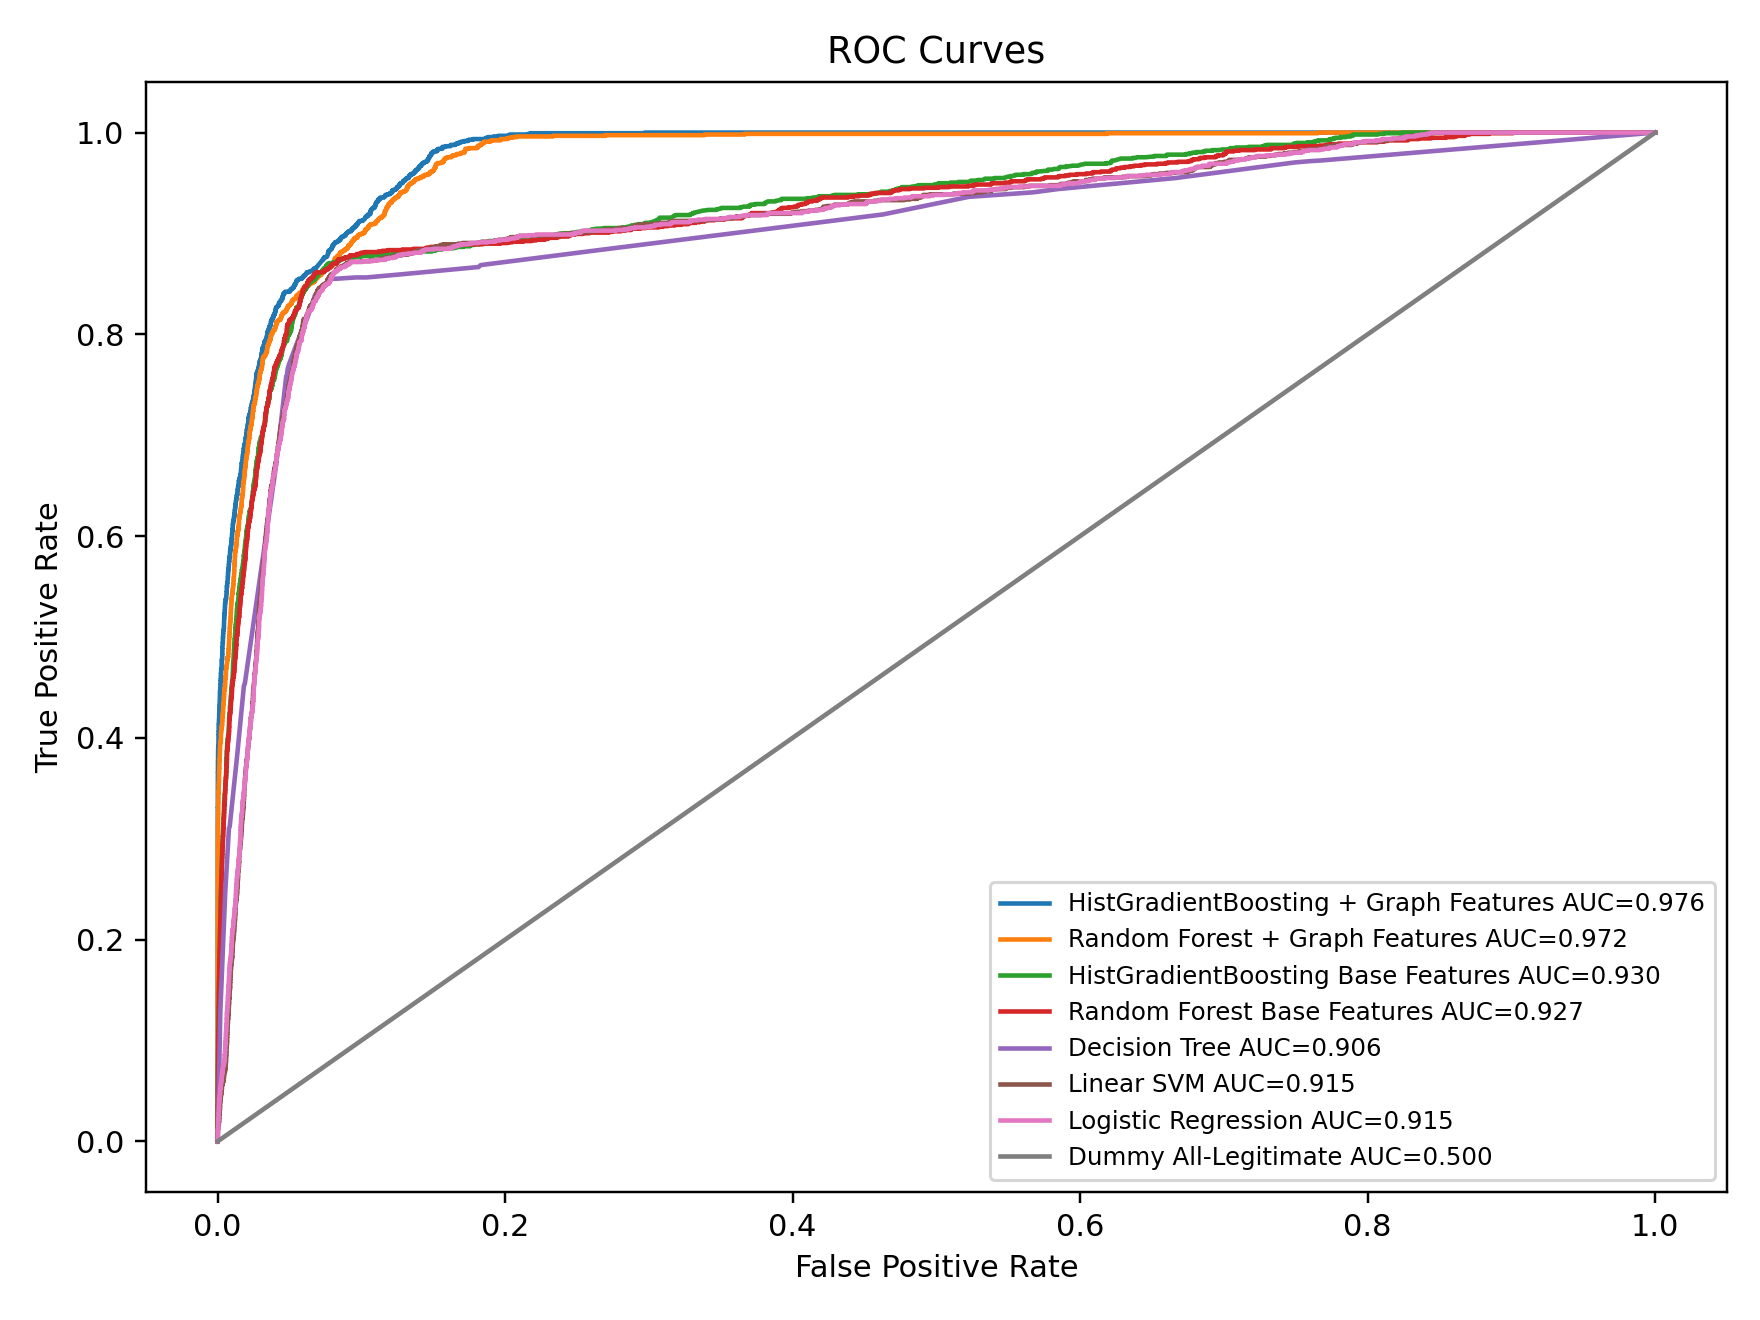

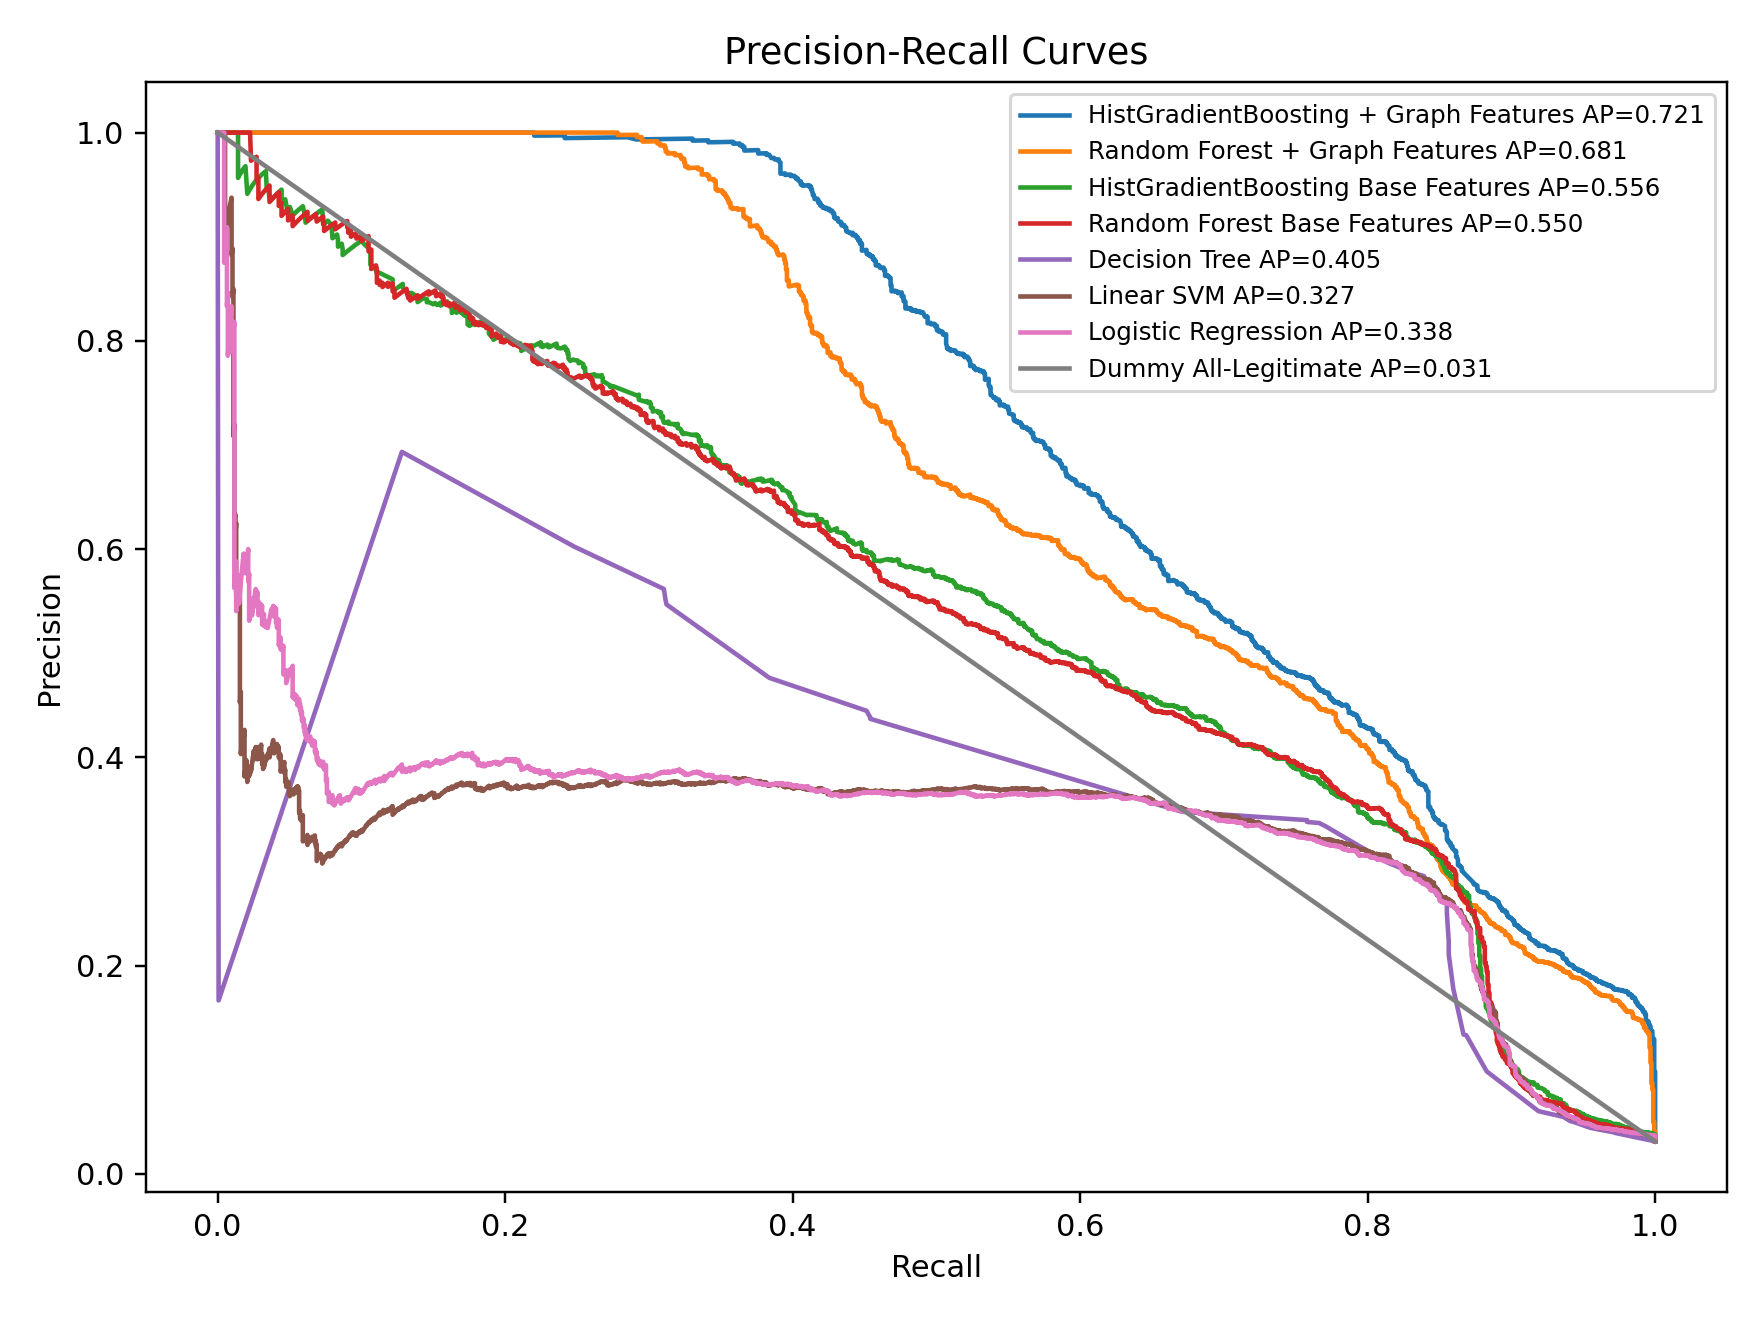

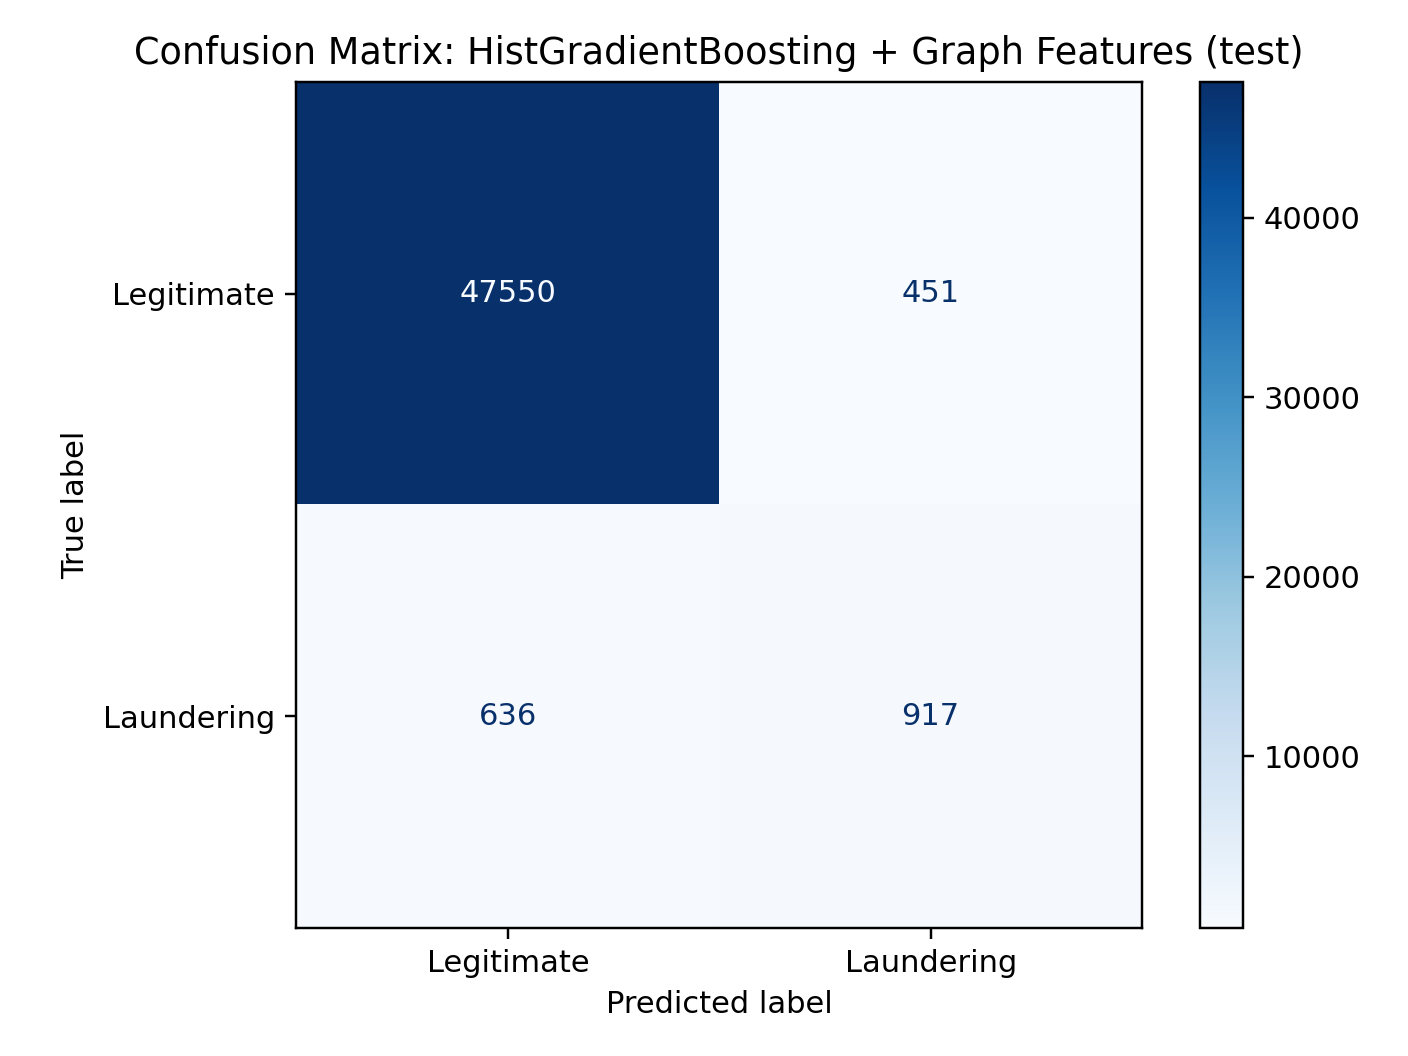

In [14]:
# Separate threshold-free ranking curves from the selected-threshold confusion matrix.
display(Image(filename=str(FIGURES/'roc_curves.png')))
display(Image(filename=str(FIGURES/'pr_curves.png')))
display(Image(filename=str(FIGURES/'confusion_matrix_histgradientboosting_plus_graph_features.png')))

The PR curve makes the ensemble advantage clearer than accuracy does. The sampled-test confusion matrix then converts that ranking into analyst-facing consequences: recovered cases, missed cases, and false alerts. We select HGB + Graph for further stress testing because it has the best sampled F1 and PR-AUC, not because every metric is perfect.


The following cell displays separate confusion matrices for train, test, and the full modeling sample. This check is useful for spotting large train-test discrepancies and for verifying that the full-sample numbers are consistent with the two component splits.


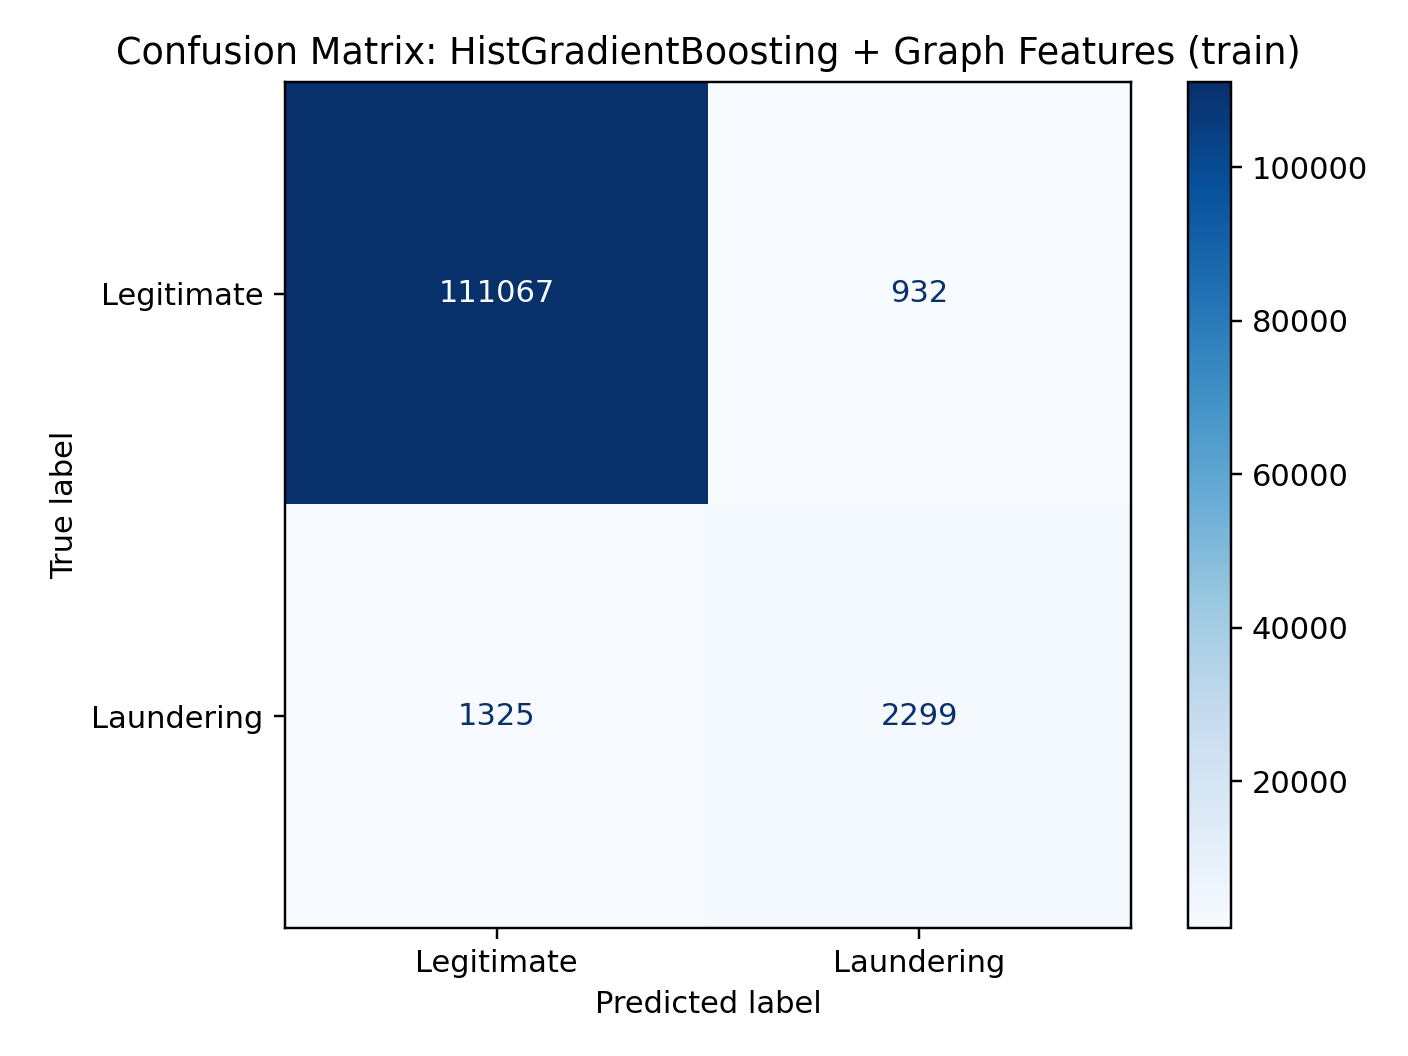

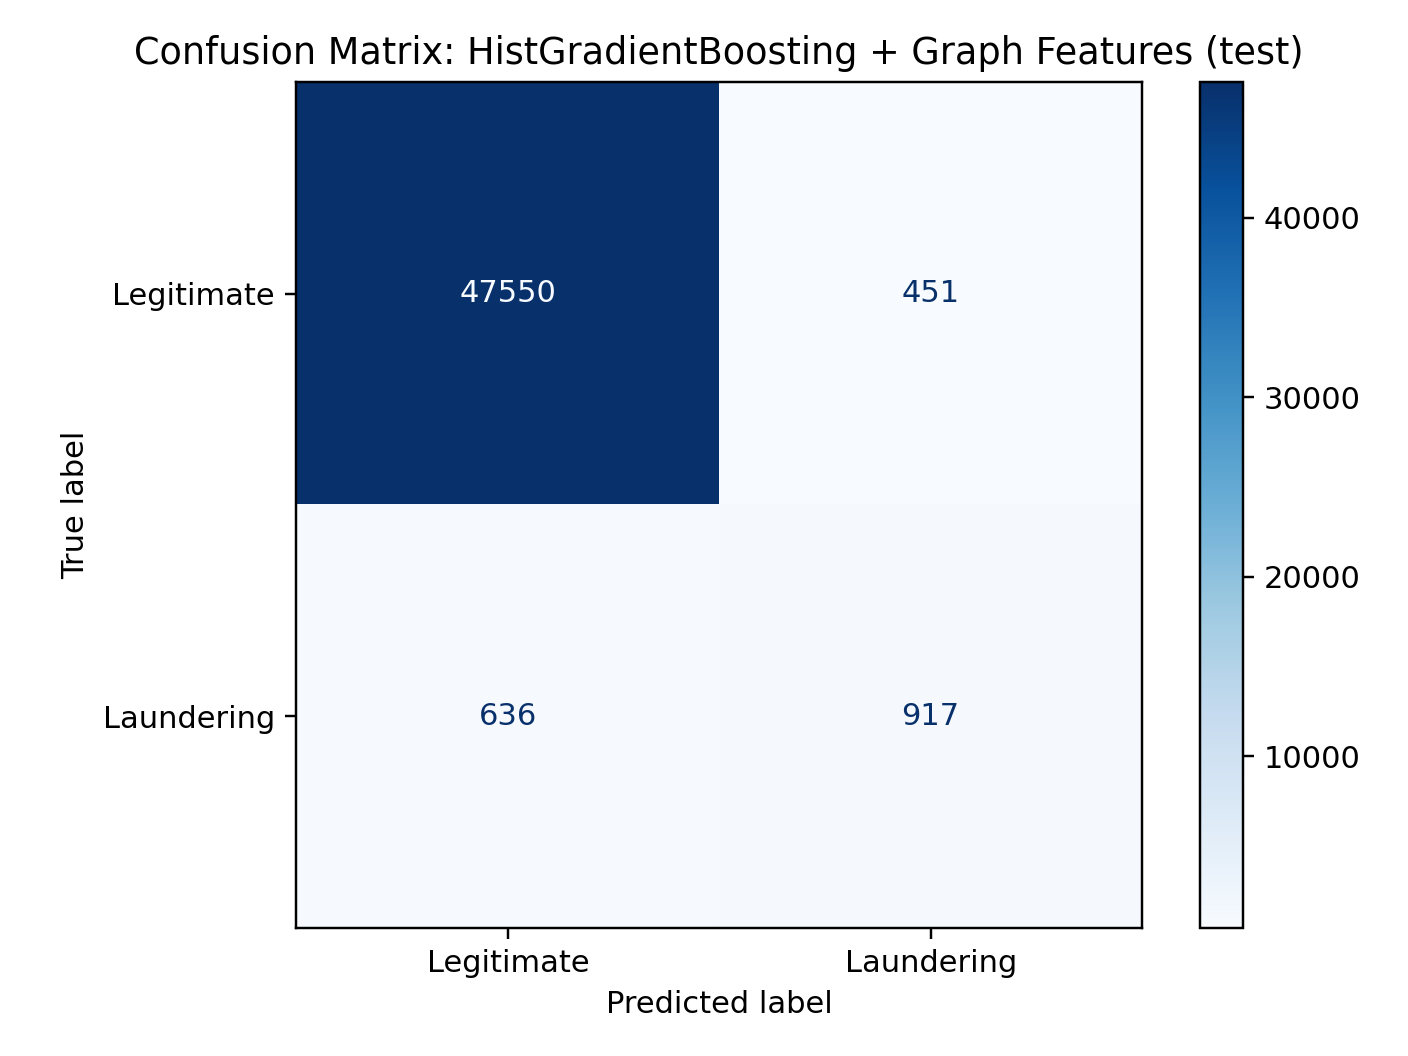

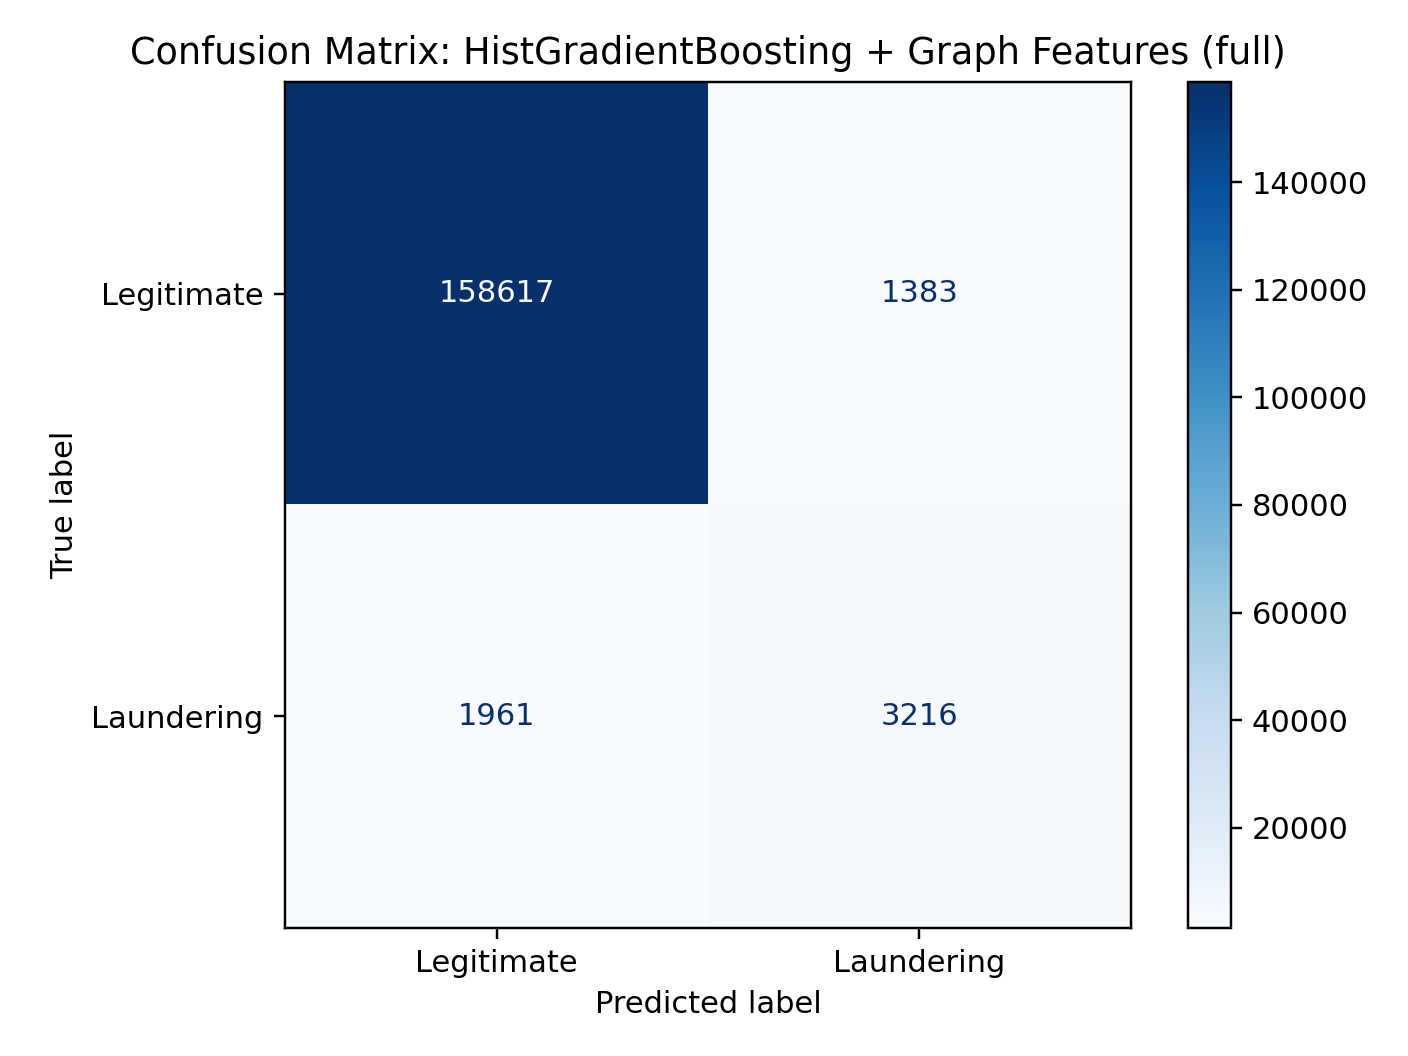

In [15]:
# Check the selected model across train, test, and their descriptive union.
display(Image(filename=str(FIGURES/'confusion_matrix_histgradientboosting_plus_graph_features_train.png')))
display(Image(filename=str(FIGURES/'confusion_matrix_histgradientboosting_plus_graph_features_test.png')))
display(Image(filename=str(FIGURES/'confusion_matrix_histgradientboosting_plus_graph_features_full.png')))

### Boundary of this result

The three matrices show reasonable internal consistency, but they share the enriched modeling design. All laundering transactions were retained while legitimate transactions were sampled, increasing the positive rate to roughly 3.13%. That design is appropriate for controlled model development, but sampled precision will be optimistic when the model returns to a stream where only about 0.10% of transactions are positive. We therefore test class-prior shift explicitly.


## 10. Natural class-prior stress test: ranking meets investigation capacity

The stress test evaluates the selected HGB + Graph model on 1,501,553 transactions with a 0.1034% positive rate, close to the full dataset. It keeps the validation-selected threshold unchanged. This isolates a central AML problem: even a low false-positive rate can create a very large number of alerts when legitimate transactions dominate.

This is a class-prior stress test, not a fully independent temporal deployment simulation. Graph construction and evaluation sampling may still contain transductive elements; chronology is tested separately later.


In [16]:
# Restore the natural class prior to measure alert pressure rather than sampled precision.
pd.read_csv(RESULTS/'natural_distribution_evaluation.csv')

,model,evaluation,rows,positive_rows,positive_rate,threshold_from_validation,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
0,HistGradientBoosting + Graph Features,natural_class_prior_stress_test,1501553,1553,0.001034,0.908468,0.933514,0.008344,0.537025,0.016433,0.90711,0.009406,1400887,99113,719,834


### Failure mode 2: good sampled ranking does not guarantee usable precision

At the selected threshold, recall remains 0.537 and ROC-AUC remains 0.907, but precision falls to **0.00834** and F1 to **0.0164**. The model creates 99,113 false positives for 834 true positives, or about **665.6 alerts per 10,000 transactions**. This is the base-rate effect in operational form.

The result does not erase the model's ranking signal. It shows that score quality and alert policy are separate engineering problems. A real system must calibrate scores under the target prevalence and select thresholds from investigator capacity.


The threshold sweep below treats alert volume as a first-class output. Each row shows how a stricter threshold changes the alert rate, precision, recall, F1, and confusion counts. This is more actionable than reporting one default threshold because AML teams typically work with a constrained daily review budget.


In [17]:
# Translate alternative thresholds into alert volume and recall trade-offs.
pd.read_csv(RESULTS/'natural_threshold_sweep.csv')

,threshold,alert_rate,alerts,precision,recall,f1,tn,fp,fn,tp
0,0.821834,0.099997,150151,0.007253,0.701223,0.014357,1350938,149062,464,1089
1,0.908468,0.066562,99947,0.008344,0.537025,0.016433,1400887,99113,719,834
2,0.947761,0.050000,75078,0.008964,0.433355,0.017565,1425595,74405,880,673
3,0.950000,0.049153,73806,0.009024,0.428847,0.017675,1426860,73140,887,666
4,0.980000,0.038250,57435,0.008967,0.331616,0.017461,1443080,56920,1038,515
5,0.990000,0.032610,48965,0.009292,0.292981,0.018013,1451490,48510,1098,455
6,0.991709,0.019944,29947,0.011253,0.216999,0.021397,1470390,29610,1216,337
7,0.992284,0.010327,15506,0.016574,0.165486,0.030131,1484751,15249,1296,257
8,0.995000,0.007626,11451,0.017902,0.132003,0.031529,1488754,11246,1348,205
9,0.996525,0.005000,7508,0.016516,0.079845,0.027370,1492616,7384,1429,124


No threshold in this sweep creates a painless solution. Reducing the alert rate from about 6.66% to around 1.03% increases precision but lowers recall from 53.7% to 16.5%. At still stricter thresholds, recall falls further. This trade-off is exactly why the threshold should be chosen with an explicit cost matrix or alert budget rather than by accuracy or F1 alone.


The natural-prior confusion matrix visualizes the scale imbalance that percentages can hide. The false-positive cell dominates because even a modest error rate is applied to roughly 1.5 million legitimate transactions.


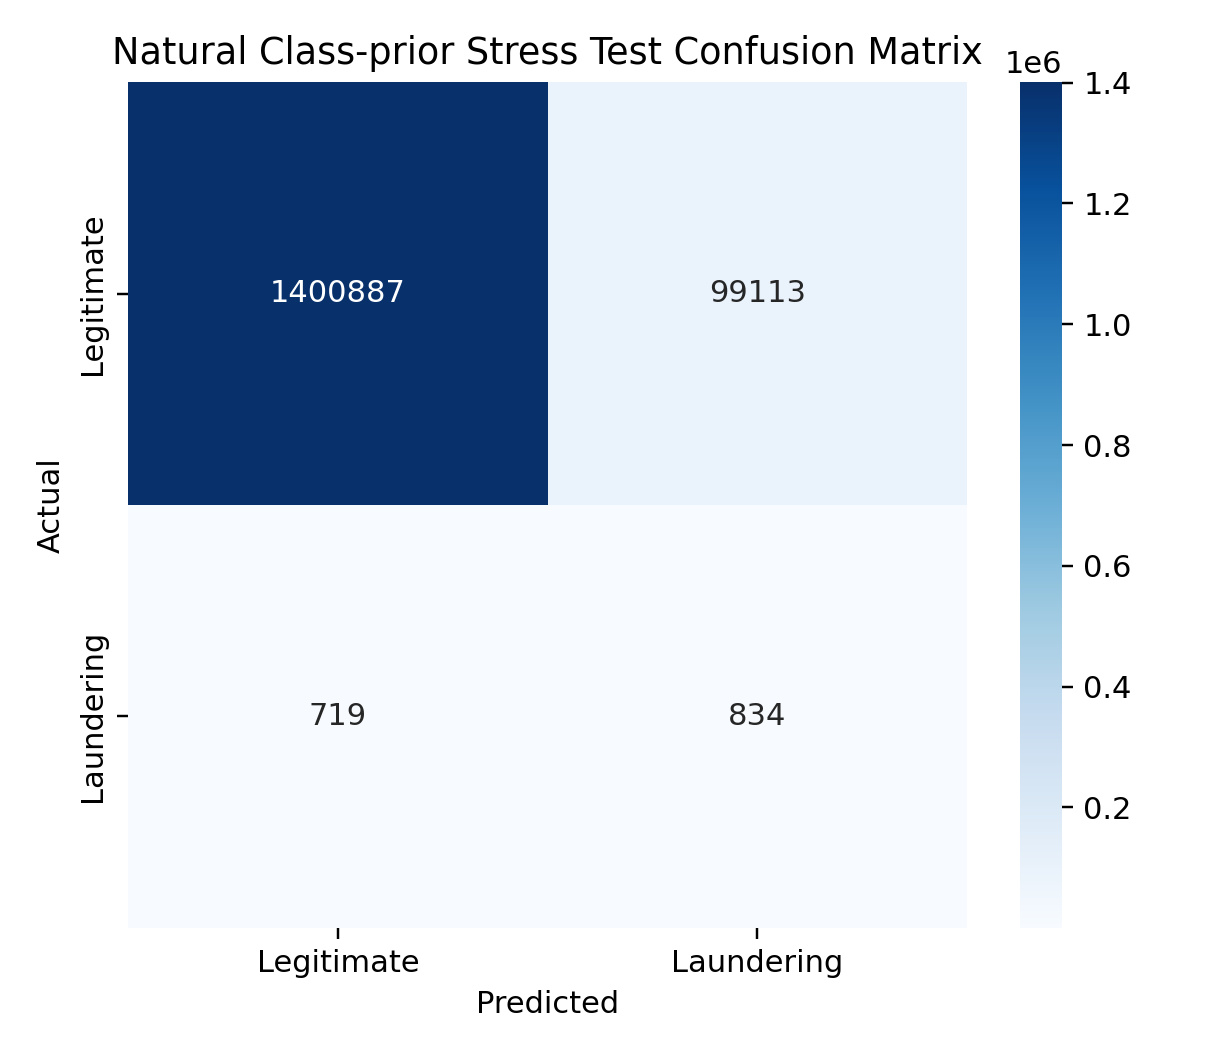

In [18]:
# Visualize the absolute false-positive burden under natural prevalence.
display(Image(filename=str(FIGURES/'confusion_matrix_natural_distribution.png')))

### Operational implication

The practical role of this model is **triage**, not automatic accusation. A score could help rank a queue and attach contextual account features for analyst review, but the current threshold would overwhelm most investigation teams. Deployment would require calibrated scores, top-k or budget-based alerting, and continuous monitoring of alert yield.


## 11. Open-ended contribution: graph features and ablation

Transaction features answer "what happened in this payment?" Graph features ask "how does this payment fit the sender's and receiver's broader behavior?" We construct directed account relationships and derive degree, unique counterparties, total sent/received amount, mean flow, PageRank, fan-in, fan-out, and scatter-gather proxies.

To test whether this context actually helps, we compare the same model family before and after adding graph features. This controlled ablation is stronger evidence than comparing unrelated algorithms.


In [19]:
# Isolate the retrospective contribution of account graph context within each model family.
pd.read_csv(RESULTS/'ablation_summary.csv')

,comparison,base_model,enhanced_model,delta_f1,delta_pr_auc
0,Random Forest: base -> graph,Random Forest Base Features,Random Forest + Graph Features,0.062398,0.130562
1,HistGradientBoosting: base -> graph,HistGradientBoosting Base Features,HistGradientBoosting + Graph Features,0.088034,0.165614


### Graph-feature gain under the random/transductive split

Adding graph context raises Random Forest F1 by 0.062 and PR-AUC by 0.131. For HGB, F1 rises by 0.088 and PR-AUC by 0.166. The agreement across two ensemble families supports the hypothesis that account behavior contains signal beyond a single transaction row **within this protocol**.

However, an ablation proves association under its data construction, not future predictive value. If graph aggregates include edges from across a randomly split modeling graph, training and test rows can share account context. This motivates the later time audit.


## 12. Feature-selection ablation: how much complexity is necessary?

Mutual information ranks encoded features by their individual dependence with the label. We retrain HGB with the top 5, 10, and 20 features and compare them with all 60 encoded base-plus-graph features. Because the model is retrained at every size, this is a genuine predictive ablation rather than a decorative importance plot.


In [20]:
# Retrain top-k MI subsets so feature selection is evaluated predictively.
pd.read_csv(RESULTS/'feature_selection_ablation.csv')

,feature_set,n_features,threshold,training_seconds,accuracy,precision,recall,f1,roc_auc,pr_auc
0,All base+graph encoded features,60.0,0.908468,2.409670,0.978064,0.670322,0.590470,0.627867,0.976154,0.721247
1,Top-5 mutual information features,5.0,0.882486,0.891370,0.967329,0.481502,0.553123,0.514834,0.962370,0.568659
2,Top-10 mutual information features,10.0,0.899354,0.911512,0.972555,0.561740,0.565357,0.563543,0.968912,0.656200
3,Top-20 mutual information features,20.0,0.903869,1.163964,0.975582,0.614105,0.594334,0.604058,0.973783,0.698680
4,All base features (pipeline result),NaN,0.898421,NaN,0.966663,0.475700,0.623954,0.539833,0.930407,0.555632
5,All graph features (pipeline result),NaN,0.908468,NaN,0.978064,0.670322,0.590470,0.627867,0.976154,0.721247


Top-5 features are too restrictive: PR-AUC falls from 0.721 to 0.569. Top-10 recover more signal (0.656), while top-20 preserve most of it (0.699) and reduce measured training time from 2.41 to 1.16 seconds. The trade-off is gradual rather than binary. We retain all features for the strongest sampled model, while top-20 is a plausible lower-complexity option for a latency-sensitive system.


The next table identifies the top 20 features. Prefixes record the preprocessing path: `cat__` indicates one-hot encoded categorical variables and `num__` indicates numeric variables passed through the numeric pipeline. Mutual information is univariate, so it can miss interactions and should be interpreted together with model-based importance and ablation results.


In [21]:
# Inspect univariate feature-label dependence after the fitted preprocessing pipeline.
pd.read_csv(RESULTS/'mutual_information_features.csv').head(20)

,feature,mutual_information
0,cat__Payment Format_ACH,0.044459
1,num__sender_mean_sent,0.032869
2,num__receiver_mean_received,0.029535
3,num__sender_total_sent,0.028263
4,num__receiver_pagerank,0.027958
5,num__receiver_total_received,0.027458
6,num__receiver_in_degree,0.026104
7,num__receiver_unique_senders,0.024203
8,num__sample_receiver_in_degree,0.022637
9,num__sender_out_degree,0.021299


The ranking combines transaction context and network behavior. ACH payment format is first, but many of the next features describe sender/receiver totals, mean flow, degree, counterparty reach, and PageRank. This mixture supports our macro hypothesis that suspiciousness is neither purely transactional nor purely structural.

It does not imply causality. A high mutual-information score says that a feature is useful in this synthetic sample, not that changing the feature would change laundering risk.


The two plots below compare univariate mutual information with the fitted model's feature importance. Agreement increases confidence that a signal is not an artifact of one explanation method; disagreement can reveal interaction effects or correlated substitutes.


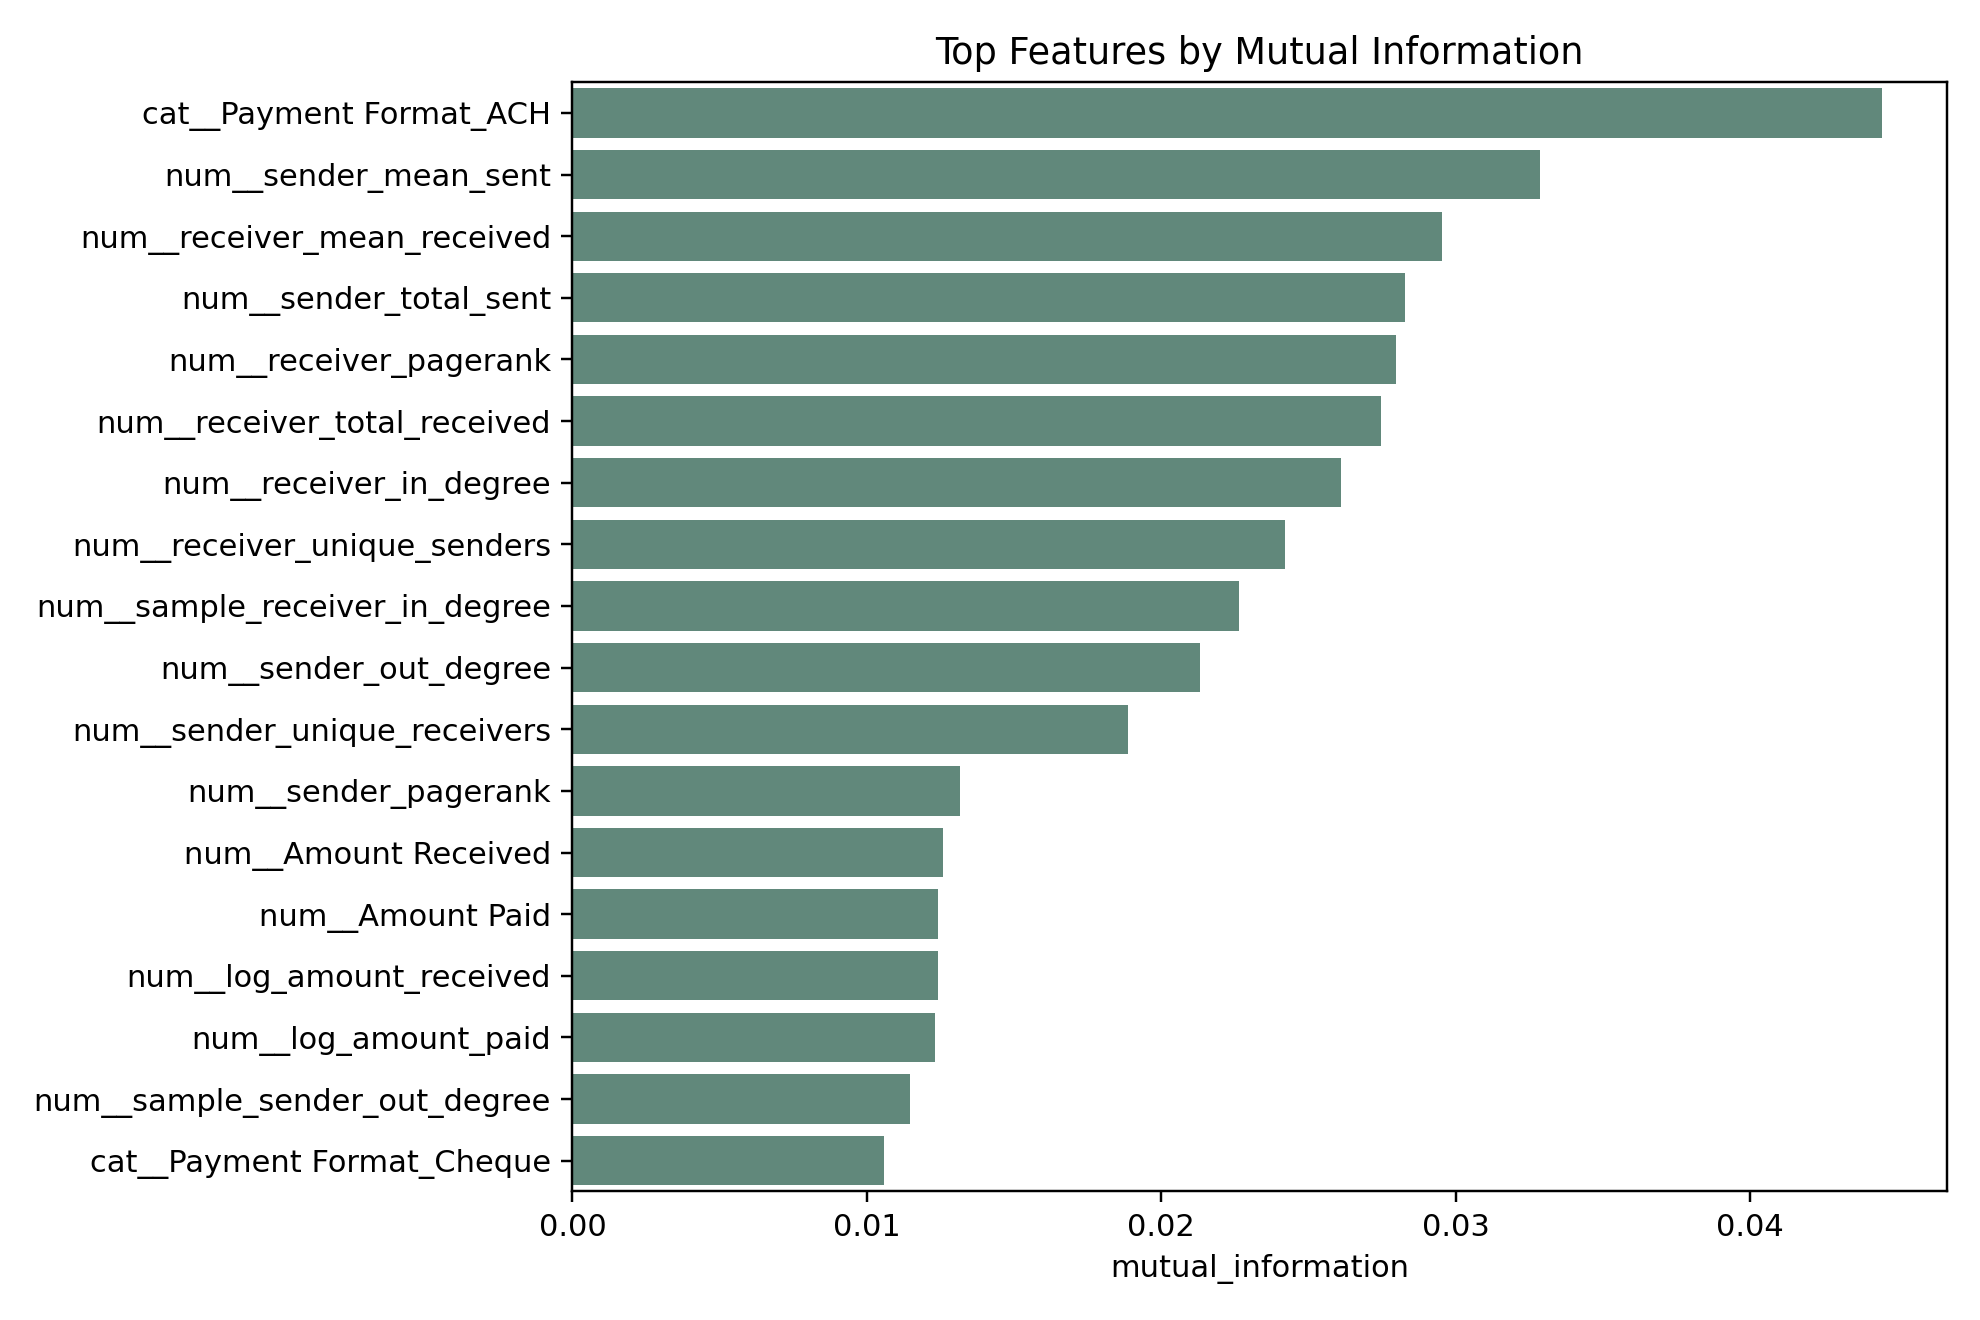

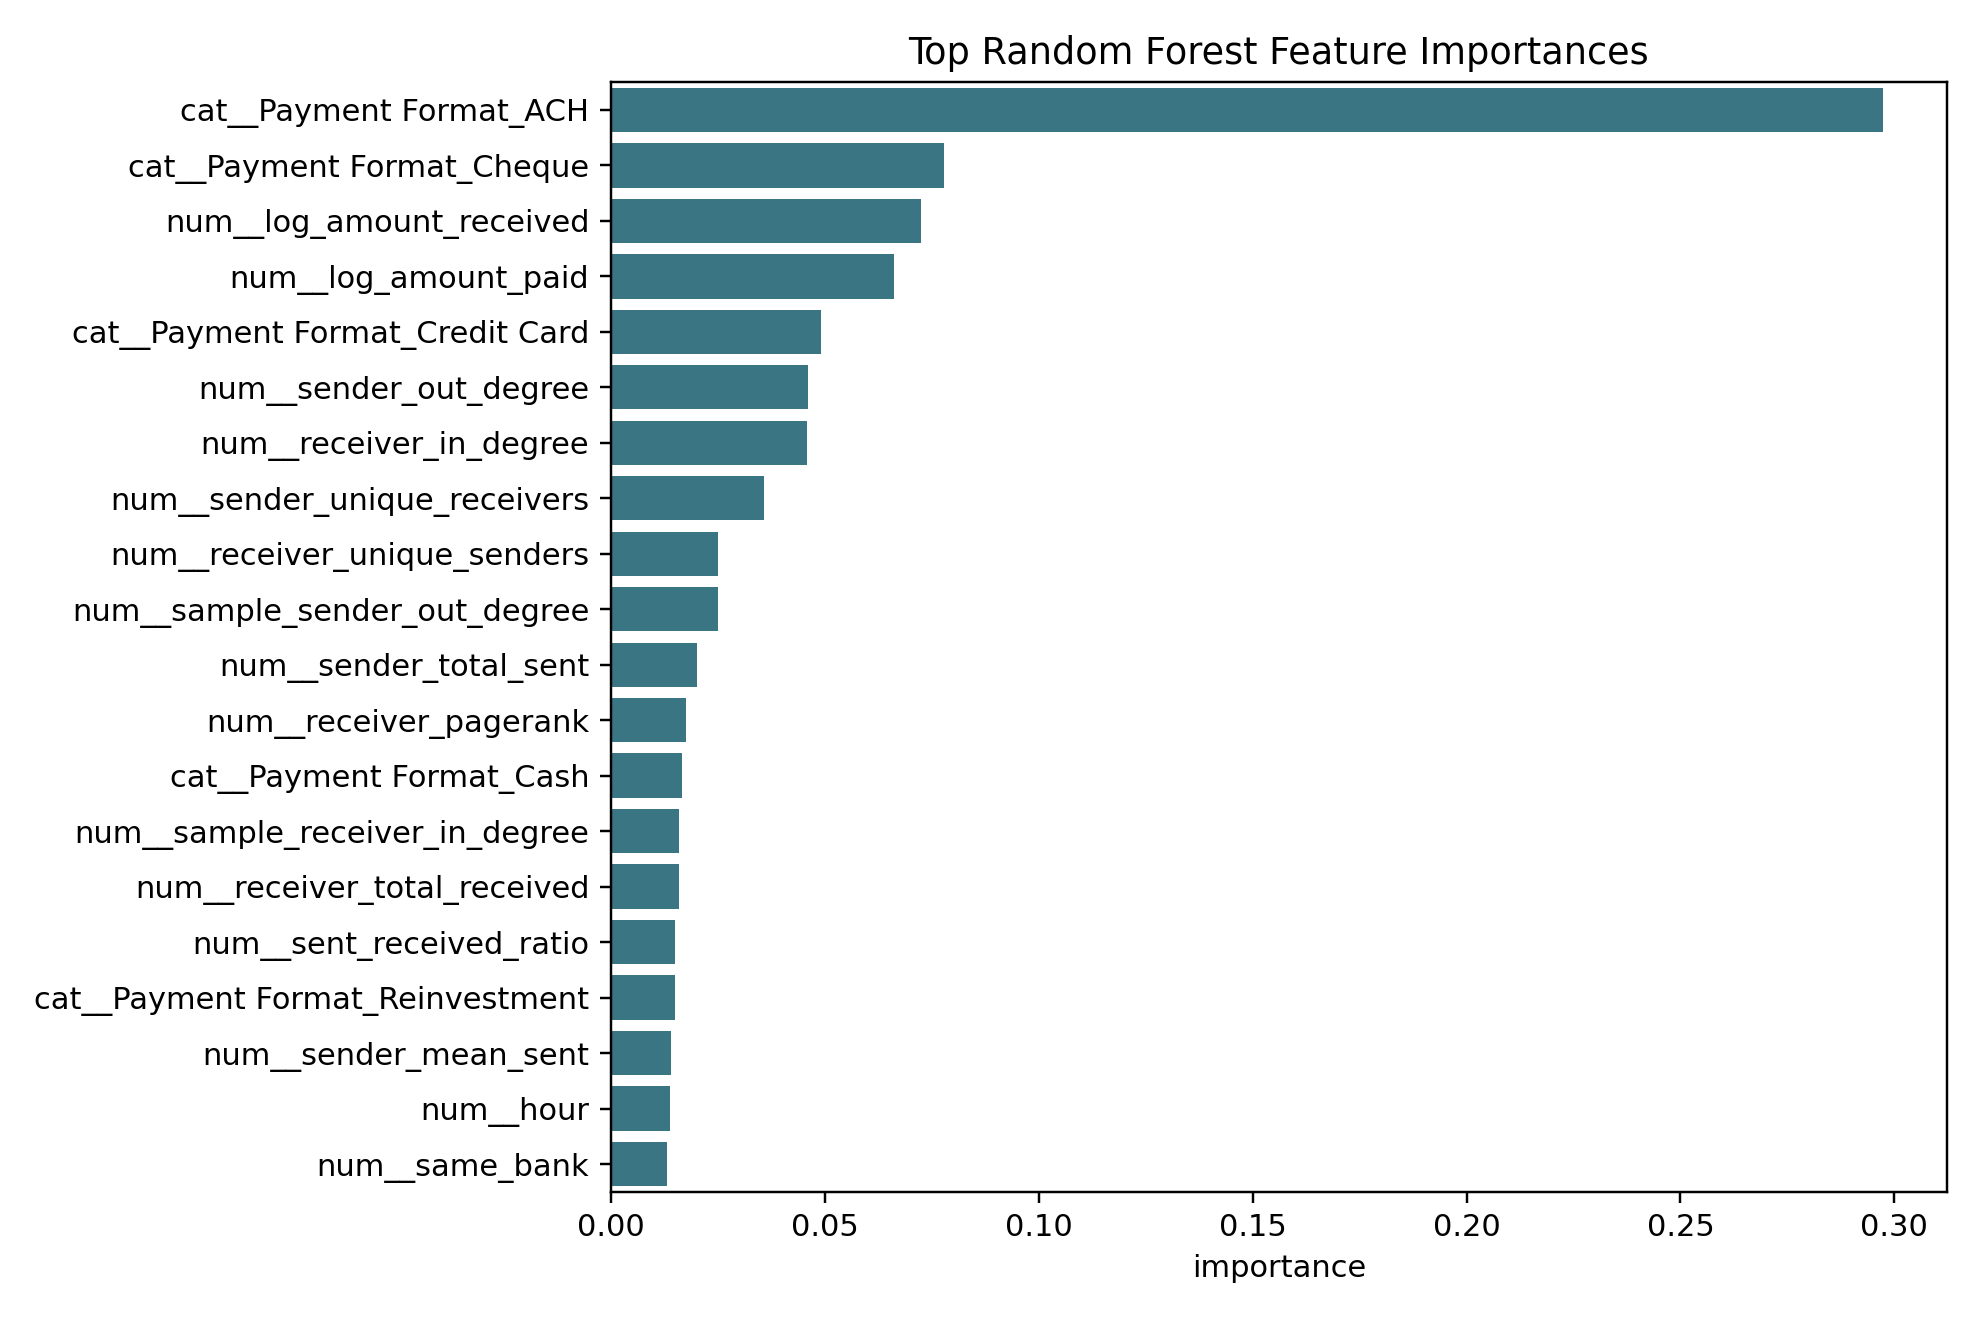

In [22]:
# Compare mutual-information ranking with model-based feature importance.
display(Image(filename=str(FIGURES/'mutual_information_features.png')))
display(Image(filename=str(FIGURES/'feature_importance.png')))

### Feature-engineering takeaway

Graph variables repeatedly appear among influential features and improve sampled ensemble performance, so the account-level representation is a meaningful project contribution. Yet the same feature family carries the greatest leakage risk because an account aggregate depends on which edges were available at feature-computation time. We therefore treat temporal validation as part of feature engineering, not merely as a final reporting check.


## 13. Temporal evaluation: failure, diagnosis, and repair

Our first time audit used a 60/20/20 chronological split but mapped one **frozen training-period graph snapshot** onto all validation and test rows. It prevented future test edges from entering the snapshot, yet it introduced a train/inference mismatch: training aggregates summarized the whole training period, while later accounts could not update as validation and test transactions arrived. The cell below preserves this failed design because it motivated the repair.

In [23]:
# Reproduce the frozen-snapshot temporal failure before testing the repaired history design.
pd.read_csv(RESULTS/'time_based_leakage_check.csv')

,protocol,model,train_rows,validation_rows,test_rows,train_positive_rate,validation_positive_rate,test_positive_rate,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,time_based_60_20_20_frozen_snapshot,"HGB Base, time split",99106,33035,33036,0.02351,0.032965,0.053215,0.910867,0.962435,0.634706,0.692833,0.662497,0.944391,0.683398
1,time_based_60_20_20_frozen_snapshot,"HGB Graph, frozen train snapshot",99106,33035,33036,0.02351,0.032965,0.053215,0.672228,0.941791,0.457930,0.510808,0.482926,0.930734,0.459319


### Failure mode 3: a frozen snapshot is not an online graph

The frozen graph model falls from base PR-AUC 0.683 to 0.459. We initially interpreted this as a warning that the random graph gain might not survive chronology. Code inspection revealed a more specific failure mode: freezing all account statistics at the training boundary makes every new test account look identical and ignores legitimate history accumulated after that boundary. The representation, not only the model, must evolve through time.

The repair computes each transaction's account and edge features **before updating state with that transaction**. Counts, totals, counterparties, repeated/reverse edges, 24-hour and 7-day activity, amount deviations, and recency therefore use strictly earlier rows. Validation observations can update history for later validation/test observations, exactly as an online monitor would, but labels are never used in feature construction.

In [24]:
# Compare independently tuned base and strict expanding-history models.
strict_time = pd.read_csv(RESULTS / "time_based_history_ablation.csv")
strict_time[
    [
        "feature_set",
        "validation_pr_auc",
        "best_params",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "pr_auc",
        "fp",
        "fn",
        "tp",
    ]
]


,feature_set,validation_pr_auc,best_params,precision,recall,f1,roc_auc,pr_auc,fp,fn,tp
0,base,0.538570,"{""class_weight"": null, ""l2_regularization"": 1....",0.639449,0.686397,0.662092,0.946448,0.712663,680,551,1206
1,strict_expanding_history,0.686883,"{""class_weight"": null, ""l2_regularization"": 1....",0.714683,0.731360,0.722925,0.979599,0.828736,513,472,1285


### Repaired temporal result

The direction is now consistent on both later periods. Validation PR-AUC rises from **0.539** with base features to **0.687** with strict history. On the final chronological test, PR-AUC rises from **0.713 to 0.829** and F1 from **0.662 to 0.723**. At the validation-selected thresholds, strict history also improves precision from 0.639 to 0.715 and recall from 0.686 to 0.731.

This is a real correction of the feature-availability problem, not a rewritten metric. Both feature sets receive the same 18-candidate temporal HGB search, parameters are chosen on validation PR-AUC, and the test period is used once.


,comparison,delta_f1,delta_pr_auc,base_pr_auc,history_pr_auc
0,base -> strict expanding history,0.060834,0.116072,0.712663,0.828736


,metric,point_estimate,ci_lower_95,ci_upper_95,bootstrap_resamples
0,paired_bootstrap_delta_pr_auc,0.116072,0.1,0.130145,500


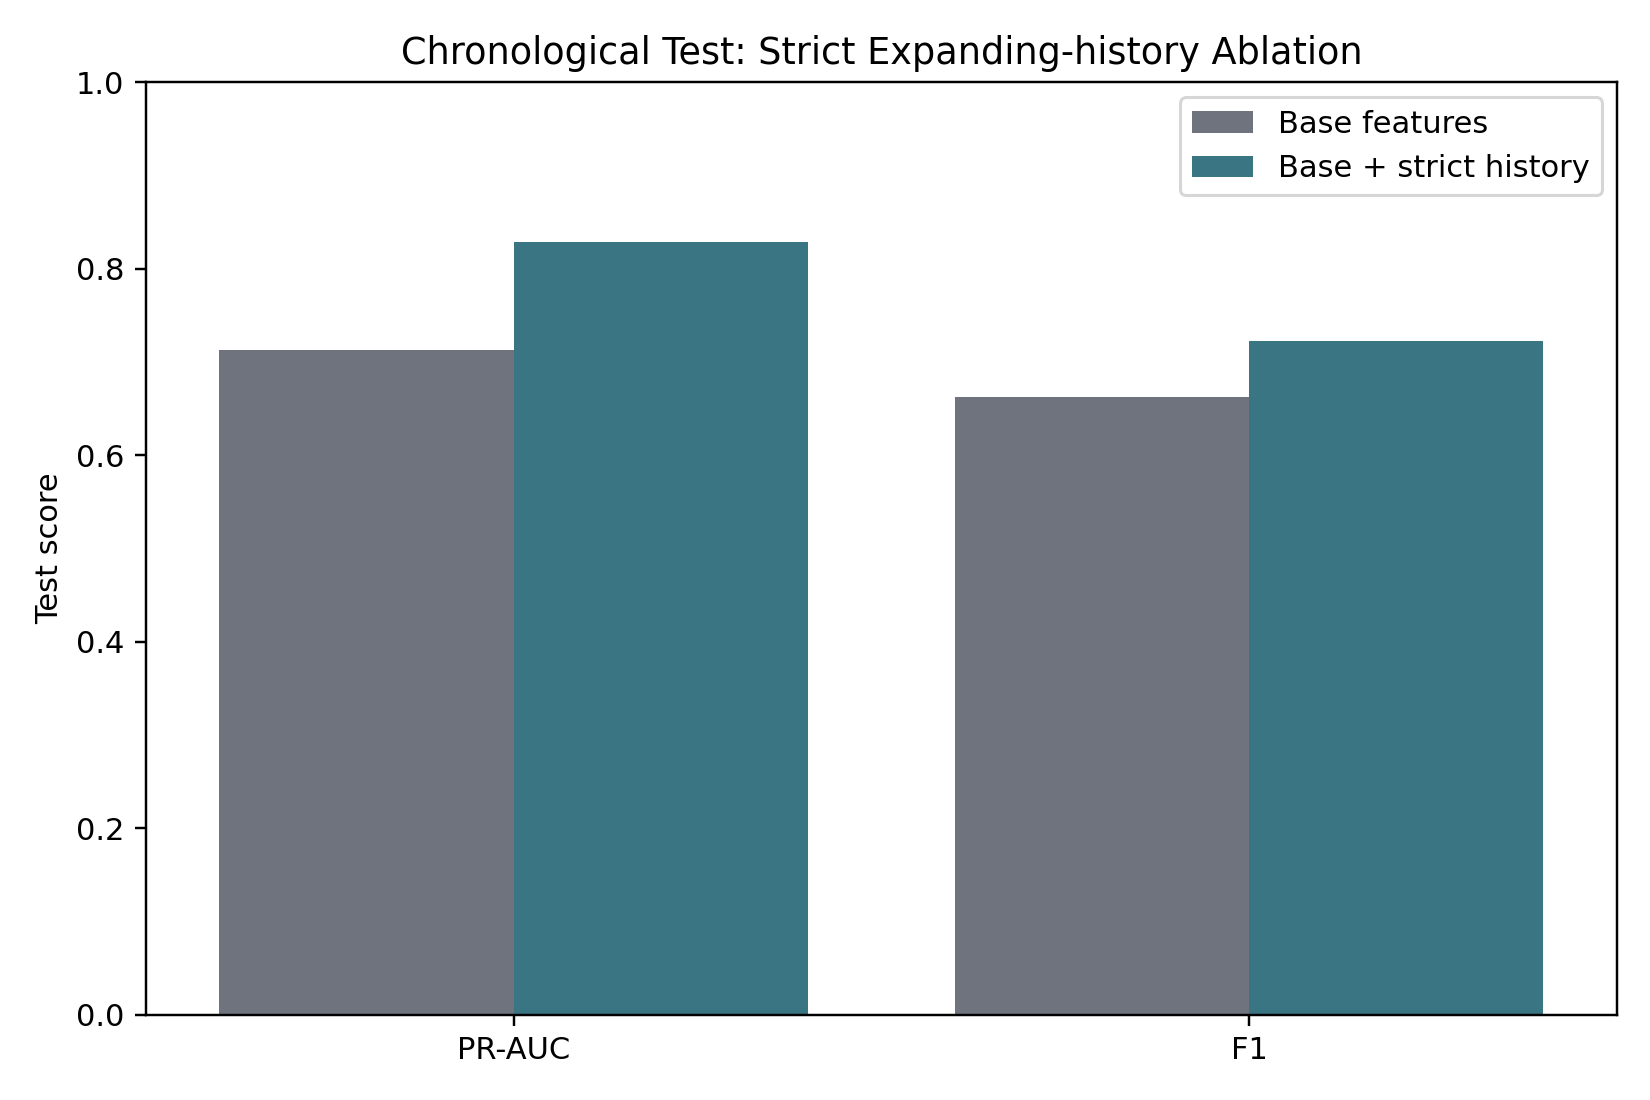

In [25]:
# Quantify the paired test improvement and its bootstrap uncertainty.
display(pd.read_csv(RESULTS / "time_based_history_ablation_delta.csv"))
display(pd.read_csv(RESULTS / "time_based_history_bootstrap_ci.csv"))
display(Image(filename=str(FIGURES / "time_based_history_ablation.png")))


The paired PR-AUC gain is **+0.116**, with a 500-resample 95% bootstrap interval of **[+0.100, +0.130]**. Because each bootstrap draw compares both models on the same transactions, the interval directly measures uncertainty in the improvement. It remains entirely above zero.

The claim is still bounded. This temporal audit uses the 165,177-row modeling sample, not the natural 0.10% class prior, and one synthetic chronological holdout cannot establish external validity. What it does show is that account context can survive chronology when features are computed as an expanding history rather than as a frozen or retrospective graph.


## 14. Final synthesis: what this study can help with

The project is best understood as a study of **AML triage design**. Transaction variables provide event evidence; account history provides behavioral context; supervised scores rank cases; and thresholds translate scores into investigator workload. A flag remains a prompt for human review, not evidence of wrongdoing.

The experiments connect three systems:

| System | Evidence in this project |
|---|---|
| Statistical | 3-fold CV, held-out tests, threshold-free PR-AUC, and paired bootstrap uncertainty |
| Data | retrospective graph ablation, failed frozen snapshot, and strict expanding-history construction |
| Operational | natural-prior stress test, threshold sweep, and alerts per 10,000 transactions |

### Evidence-based conclusion

- Mandatory preprocessing, t-SNE, KMeans/DBSCAN, supervised training, train/test/full evaluation, confusion matrices, ROC/AUC, and validation are complete.
- Formal GridSearchCV confirms HGB as the strongest model family and reports fold-level uncertainty rather than one validation score.
- Retrospective graph features achieve mean CV PR-AUC 0.721 and test PR-AUC 0.723 within the random modeling protocol.
- A frozen training snapshot fails under chronology, revealing a feature-construction mismatch rather than just a weak classifier.
- Strict expanding-history features repair that mismatch and improve chronological test PR-AUC from 0.713 to 0.829, with paired delta 95% CI [+0.100, +0.130].
- Natural prevalence still creates severe alert pressure, so score calibration and review-budget thresholds remain necessary.

The strongest conclusion is therefore conditional but constructive: **account behavior improves AML ranking when graph features are computed from information genuinely available before each transaction**. A deployment study would still require full-stream historical construction, natural-prior out-of-time evaluation, account-disjoint testing, realistic label delay, and analyst feedback.

## 15. Complete implementation appendix

The following code cell displays the complete source of all three executable ML modules included in the submission. This makes the notebook self-contained for technical review while preserving the scripts as reusable command-line entry points. Each module uses relative project paths and can be executed from the extracted root.


In [26]:
# Display every line of the submitted core implementation inside the notebook.
from IPython.display import Code

for source_name in [
    "aml_project_pipeline.py",
    "aml_project_enhancements.py",
    "aml_project_model_selection.py",
]:
    print(f"\n===== src/{source_name} =====")
    display(Code(filename=str(ROOT / "src" / source_name), language="python"))



===== src/aml_project_pipeline.py =====


"""Core DSAA2011 AML pipeline.

The script processes the complete transaction file in chunks for descriptive
statistics, creates the reproducible modeling sample, engineers transaction and
retrospective account features, and runs the mandatory visualization,
clustering, supervised-learning, and evaluation tasks.
"""

from __future__ import annotations

import json
import math
import shutil
import urllib.request
import zipfile
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    calinski_harabasz_score,
    classification_report,
    confusion_matrix,
    davies_bouldin_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier


ROOT = Path(__file__).resolve().parents[1]
DATA_ZIP = ROOT / "data" / "HI-Small_Trans.csv.zip"
DATA_URL = (
    "https://huggingface.co/datasets/eexzzm/"
    "IBM-Transactions-for-Anti-Money-Laundering-HI-Small-Trans/resolve/main/"
    "HI-Small_Trans.csv.zip?download=true"
)
FIGURES = ROOT / "figures"
RESULTS = ROOT / "results"
RANDOM_STATE = 42


# ---------- Data access and full-dataset descriptive statistics ----------


def ensure_dirs() -> None:
    for path in [ROOT / "data", FIGURES, RESULTS]:
        path.mkdir(parents=True, exist_ok=True)


def ensure_data() -> None:
    if DATA_ZIP.exists():
        return
    print(f"Downloading dataset to {DATA_ZIP}...")
    urllib.request.urlretrieve(DATA_URL, DATA_ZIP)


def csv_name_in_zip() -> str:
    with zipfile.ZipFile(DATA_ZIP) as zf:
        names = [name for name in zf.namelist() if name.lower().endswith(".csv")]
    if not names:
        raise FileNotFoundError(f"No CSV file found in {DATA_ZIP}")
    return names[0]


def first_pass_stats(chunksize: int = 500_000) -> dict:
    total_rows = 0
    positive_rows = 0
    payment_counts = {}
    payment_pos = {}
    currency_counts = {}
    currency_pos = {}
    hourly_counts = {}
    hourly_pos = {}
    amount_by_label = {0: [], 1: []}

    name = csv_name_in_zip()
    with zipfile.ZipFile(DATA_ZIP) as zf:
        for chunk in pd.read_csv(zf.open(name), chunksize=chunksize):
            chunk["Timestamp"] = pd.to_datetime(chunk["Timestamp"], errors="coerce")
            chunk["hour"] = chunk["Timestamp"].dt.hour
            total_rows += len(chunk)
            positive_rows += int(chunk["Is Laundering"].sum())

            for col, count_map, pos_map in [
                ("Payment Format", payment_counts, payment_pos),
                ("Payment Currency", currency_counts, currency_pos),
                ("hour", hourly_counts, hourly_pos),
            ]:
                counts = chunk.groupby(col, dropna=False).size()
                poss = chunk.groupby(col, dropna=False)["Is Laundering"].sum()
                for key, value in counts.items():
                    count_map[str(key)] = count_map.get(str(key), 0) + int(value)
                for key, value in poss.items():
                    pos_map[str(key)] = pos_map.get(str(key), 0) + int(value)

            for label in [0, 1]:
                vals = chunk.loc[chunk["Is Laundering"] == label, "Amount Paid"].dropna()
               


===== src/aml_project_enhancements.py =====


"""Open-ended AML experiments built on the core course pipeline.

This module contains account-level clustering, mutual-information feature
selection, feature-set ablations, the natural class-prior stress test, and the
legacy frozen-snapshot time audit retained as a documented failure mode.
"""

from __future__ import annotations

import json
import time
import zipfile
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    adjusted_rand_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    normalized_mutual_info_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from aml_project_pipeline import (
    BASE_NUMERIC,
    CATEGORICAL,
    DATA_ZIP,
    FIGURES,
    GRAPH_NUMERIC,
    RANDOM_STATE,
    RESULTS,
    add_features,
    add_graph_features,
    csv_name_in_zip,
    make_preprocessor,
)


RAW_COLUMNS = [
    "Timestamp",
    "From Bank",
    "Account",
    "To Bank",
    "Account.1",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",
]


ACCOUNT_FEATURES = [
    "sent_count",
    "received_count",
    "total_sent",
    "total_received",
    "mean_sent",
    "mean_received",
    "unique_receivers",
    "unique_senders",
    "in_out_count_ratio",
    "in_out_amount_ratio",
    "net_amount_flow",
    "fan_out_score",
    "fan_in_score",
    "scatter_gather_score",
    "max_sent_per_hour",
    "max_received_per_hour",
]


# ---------- Account-level clustering ----------


def purity_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = y_pred != -1
    if mask.sum() == 0:
        return 0.0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    total = 0
    for cluster in np.unique(y_pred):
        labels, counts = np.unique(y_true[y_pred == cluster], return_counts=True)
        if len(counts):
            total += int(counts.max())
    return total / len(y_true)


def build_account_features(df: pd.DataFrame) -> pd.DataFrame:
    sent = df.groupby("from_account_id").agg(
        sent_count=("to_account_id", "size"),
        total_sent=("Amount Paid", "sum"),
        mean_sent=("Amount Paid", "mean"),
        unique_receivers=("to_account_id", "nunique"),
        sent_laundering=("Is Laundering", "max"),
    )
    received = df.groupby("to_account_id").agg(
        received_count=("from_account_id", "size"),
        total_received=("Amount Received", "sum"),
        mean_received=("Amount Received", "mean"),
        unique_senders=("from_account_id", "nunique"),
        received_laundering=("Is Laundering", "max"),
    )
    accounts = sent.join(received, how="outer").fillna(0)
    accounts.index.name = "account_id"
    accounts = accounts.reset_index()

    sent_hour = (
        df.groupby(["from_account_id", "hour"]).size().groupby(level=0).max().rename("max_sent_per_hour")
    )
    received_hour = (
        df.groupby(["to_account_id", "hour"]).size().groupby(level=0).max().rename("max_received_per_hour")
    )
    accounts = accounts.merge(sent_hour, left_on="account_id", right_index=True, how="left")
    accounts = accounts.merge(received_hour, left_on="account_id", right_index=True, how="left")
    accounts[["max_sent_per_hour", "max_received_per_hour"]] = accounts[
        ["max_sent_per_hour", "max_received_per_hour"]
    ].fillna(0)

    accounts["account_laundering"] = (
        (accounts["sent_laundering"] > 0) | (accounts["rece


===== src/aml_project_model_selection.py =====


"""Formal model selection and leakage-safe temporal graph experiments.

This module extends the original course pipeline in two ways:

1. It performs training-set-only GridSearchCV with PR-AUC as the refit metric.
2. It constructs graph/history features in chronological order, so every row
   uses only transactions that occurred earlier in time.

The legacy random/transductive and frozen-history results remain in the
submission as failure modes. New results are written to separate artifacts.
"""

from __future__ import annotations

import json
import time
from collections import defaultdict, deque
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

from aml_project_pipeline import (
    BASE_NUMERIC,
    CATEGORICAL,
    GRAPH_NUMERIC,
    RANDOM_STATE,
    RESULTS,
    FIGURES,
    add_features,
    make_preprocessor,
)


RAW_COLUMNS = [
    "Timestamp",
    "From Bank",
    "Account",
    "To Bank",
    "Account.1",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
    "Is Laundering",
]


HISTORY_NUMERIC = [
    "hist_sender_sent_count",
    "hist_sender_received_count",
    "hist_receiver_received_count",
    "hist_receiver_sent_count",
    "hist_sender_unique_receivers",
    "hist_receiver_unique_senders",
    "hist_pair_count",
    "hist_reverse_pair_count",
    "hist_sender_total_sent",
    "hist_receiver_total_received",
    "hist_sender_mean_sent",
    "hist_receiver_mean_received",
    "hist_sender_out_in_ratio",
    "hist_receiver_in_out_ratio",
    "hist_sender_hours_since_sent",
    "hist_receiver_hours_since_received",
    "hist_sender_sent_24h",
    "hist_receiver_received_24h",
    "hist_sender_sent_7d",
    "hist_receiver_received_7d",
    "hist_amount_vs_sender_mean",
    "hist_amount_vs_receiver_mean",
    "hist_sender_seen",
    "hist_receiver_seen",
    "hist_pair_seen",
    "hist_reverse_pair_seen",
]


def _best_f1_threshold(y_true: pd.Series, scores: np.ndarray) -> tuple[float, float]:
    """Select an operating threshold without using held-out test labels."""
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    if not len(thresholds):
        return 0.5, 0.0
    f1 = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
    idx = int(np.nanargmax(f1))
    return float(thresholds[idx]), float(f1[idx])


def _classification_metrics(y_true: pd.Series, scores: np.ndarray, threshold: float) -> dict:
    """Return rare-event metrics and confusion counts for one operating point."""
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "accuracy": float((pred == y_true.to_numpy()).mean()),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, scores)),
        "pr_auc": float(average_precision_score(y_true, scores)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def _model_pipeline(model, numeric_features: list[str]) -> Pipeline:
    """Keep imputation, scaling, and one-hot encoding inside every CV fold."""
    return Pipeline(
        [
            ("preprocess", mak

This appendix is intentionally last so that a reviewer can follow the research narrative first and inspect every implementation detail afterward. The saved outputs above remain tied to their generating CSV/JSON/PNG artifacts, while full regeneration is available through the switch in Section 2.
